# CO₂ 2026: cero de sensor, inicio gradual y validación cruzada

## Resultado que se evalúa

Esta corrida corrige dos fuentes de la cola inicial artificial: la activación casi escalonada de la fuente biológica y la liberación gaseosa nula hasta superar la saturación. La comparación primaria conserva la respuesta de N pero usa la liberación por umbral anterior; el modelo lento legado se conserva como referencia histórica.

- Antes de filtrar, cada corrida recibe una corrección de cero en sccm estimada con el percentil 10 de sus primeras 12 h. El cero no se comparte entre campañas.
- Los archivos exponen canales físicos F1–F3. DOE-F06 conserva la etiqueta solicitada `sensor 6`, aunque se adquiere por F3; el offset se estima por corrida y no depende de agrupar ambas etiquetas.
- La química define el intervalo admisible de activación. Dos parámetros compartidos por matriz sitúan el comienzo y la duración de una rampa suave dentro de esa evidencia; no se estima un retardo libre por lote.
- `O2_qmax_mg_gdw_h` y `O2_initial_scale` se estiman por matriz junto con transferencia, solubilidad y ganancia.
- La fase gaseosa puede recibir un flujo pequeño desde que existe CO₂ disuelto; ya no se exige superar (C^*_{CO_2}) para abandonar exactamente cero.
- El efecto del pulso se construye como la diferencia causal entre simulaciones upstream con y sin adición de N. `pulse_t_rise_h` distribuye su disponibilidad en el tiempo y `pulse_activity_gain` representa capacidad metabólica adicional sin convertirla automáticamente en biomasa.
- En LAB el pulso se ubica por cruce de densidad 1040 g/L; en DOE-F0X se respeta el tiempo de proceso ya registrado en cada fermentación.
- Todos los gráficos de perfil de CO₂ marcan el instante del pulso nutricional.
- A setpoint ≤15.5 °C se usa un umbral operacional más conservador de 0.10 g CO₂ L⁻¹ h⁻¹; en el resto, 0.05.
- Se calibran por separado mosto sintético y natural. DOE-F06 y LAB012 son holdouts completos; después se cruzan los modelos sin reajuste.
- Se excluyen LAB001–LAB003, LAB009 y DOE-F02 por perfiles no confiables.

La analítica química sigue definiendo t=0 y el término del proceso. Esta es una validación de la capa CO₂ condicionada por los drivers upstream disponibles, no una recalibración end-to-end del modelo de fermentación.

## Estructura del modelo

Para la corrida (r), primero se corrige el cero instrumental en la señal nativa:

\[
b_r=\max\left[0,Q_{0.10}\{y_{sccm}(t):t\leq t_0+12\,h\}\right],\qquad
y_{corr}(t)=\max[y_{sccm}(t)-b_r,0]
\]

La conversión a g L⁻¹ h⁻¹, el filtrado de transientes y el suavizado ocurren después. Esta regla supone que el extremo inferior de las primeras 12 h representa cero instrumental; si ya existe flujo biológico durante toda esa ventana, puede sustraer parte de la señal real.

La primera muestra química que cumple pérdida de glucosa+fructosa ≥5 g/L o aumento de etanol ≥2 g/L marca el extremo superior del intervalo de activación. La muestra química anterior fija el extremo inferior. La fuente usa una rampa *smoothstep* continua:

\[
t_s=t_L+f_s(t_U-t_L),\quad
\Delta t=f_d(t_U-t_L),\quad
a_{chem}=3z^2-2z^3,\quad
z=\operatorname{clip}\!\left(\frac{t-t_s}{\Delta t},0,1\right)
\]

Los parámetros (f_s) y (f_d) son compartidos por matriz. Esto permite un aumento pequeño y gradual desde (t_s), pero mantiene el comienzo ligado al bracket químico en vez de introducir una latencia independiente por fermentación.

\[
\frac{dO_2}{dt}=-q_{O_2,max}X\frac{O_2}{K_{O_2}+O_2},\qquad
\phi_{ana}=\frac{K_{ana}^{h}}{K_{ana}^{h}+O_2^{h}}
\]

\[
q_{prod}=a_{chem}(t)\left[q_{bio}\left(f_{Crabtree}+(1-f_{Crabtree})\phi_{ana}\right)+q_{resp}\right]
\]

Para una adición en \(t_N\), la fracción utilizada es causal:

\[
f_N(t)=\operatorname{clip}\left(\frac{t-t_N}{t_{rise}},0,1\right),\qquad
q_{bio,N}=\left[1+(g_N-1)f_N(t)\right]q_{bio,0}
+f_N(t)\left(q_{bio,+N}-q_{bio,0}\right)
\]

La biomasa usa la misma diferencia con/sin pulso, pero sin \(g_N\). Así, el término de actividad puede capturar el aumento de capacidad de transporte descrito por el grupo de Sablayrolles sin imponer crecimiento ficticio.

\[
C^*_{CO_2}=s_{sat}\,1.69\,e^{-0.032(T-20)}e^{0.0016E}e^{-0.0012(G+F)}
\]

\[
\frac{dC_{CO_2}}{dt}=q_{prod}-q_{gas},\qquad
q_{gas}=\min\!\left[k_{release}C_{CO_2}
\left(f_0+(1-f_0)\frac{C_{CO_2}}{C_{CO_2}+C^*_{CO_2}}\right),
\frac{C_{CO_2}}{\Delta t}+q_{prod}\right],\quad f_0=0.05
\]

La formulación anterior, usada como comparador directo, tenía (q_{gas}=k_{release}\operatorname{softplus}(C_{CO_2}-C^*_{CO_2})): eso mantenía la predicción pegada a cero hasta acumular suficiente CO₂ disuelto. El nuevo piso (f_0) representa liberación sub-saturada pequeña y evita ese umbral duro.

El inicio observado se define como el primero de tres puntos horarios consecutivos sobre el mayor valor entre: límite de detección local y línea base inicial +10 % del rango dinámico. Además se reporta la primera emisión sostenida sobre 0.005 g L⁻¹ h⁻¹ y la duración visual 2–10 % del ascenso. El ajuste conserva el residuo de tiempo de inicio y, en lotes pulsados, el desfase del máximo durante las 72 h posteriores a la adición, además de los residuos del perfil completo.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython import get_ipython
from IPython.display import display

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT.name != "pyomo-doe" and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if ROOT.name != "pyomo-doe":
    raise RuntimeError("Execute this notebook from the repository or a descendant")

FM = ROOT / "fermentation_model"
for path in (FM, FM / "laboratory_2026", FM / "pilot_2025"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from laboratory_2026 import run_co2_matrix_cross_validation_2026 as analysis

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)
print("Repository:", ROOT)
print("Current model:", analysis.MODEL_NAME)
print("Direct comparator:", analysis.THRESHOLD_RELEASE_MODEL_NAME)
print("Historical comparator:", analysis.LEGACY_MODEL_NAME)
print("Holdouts:", analysis.HOLDOUTS)
print("Excluded:", analysis.EXCLUDED_BATCHES)

Repository: D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe
Current model: solubility_o2_nitrogen_boost_continuous_release
Direct comparator: solubility_o2_nitrogen_boost_threshold_release
Historical comparator: solubility_o2_slow_transition
Holdouts: {'synthetic': 'lot2_F3', 'natural': 'LAB012'}
Excluded: {'LAB001': 'discarded: unreliable CO2 implementation/profile', 'LAB002': 'discarded: unreliable CO2 implementation/profile', 'LAB003': 'discarded: unreliable CO2 implementation/profile', 'LAB009': 'discarded: unreliable CO2 implementation/profile', 'lot1_F2': 'discarded: unreliable CO2 implementation/profile (DOE-F02)'}


## Ejecución completa y partición experimental

,matrix,batch,experiment_code,reason,used_for_calibration,used_for_validation,shown_in_profile_figures
0,natural,LAB001,LAB001,discarded: unreliable CO2 implementation/profile,False,False,False
1,natural,LAB002,LAB002,discarded: unreliable CO2 implementation/profile,False,False,False
2,natural,LAB003,LAB003,discarded: unreliable CO2 implementation/profile,False,False,False
3,natural,LAB009,LAB009,discarded: unreliable CO2 implementation/profile,False,False,False
4,synthetic,lot1_F2,DOE-F02,discarded: unreliable CO2 implementation/profi...,False,False,False


,matrix,experiment_code,batch,lot,calibratable,split,acquisition_channel,sensor_id,sensor_zero_offset_sccm,n_co2_hourly,chemistry_first_h,chemistry_last_h,co2_first_h,co2_last_h,co2_peak_g_l_h,median_setpoint_c,n_artifacts_replaced,n_left_censored_hourly,note
0,natural,LAB004,LAB004,natural_2026,True,calibration,F1,1,0.00000,162,0.0,163.0,1.666667,162.833333,0.806835,18.0,19,65,
1,natural,LAB005,LAB005,natural_2026,True,calibration,F2,2,0.62066,162,0.0,163.0,1.666667,162.833333,0.706014,18.0,1,43,
2,natural,LAB006,LAB006,natural_2026,True,calibration,F3,3,0.52838,210,0.0,211.0,1.666667,210.833333,0.409412,16.0,2,71,
3,natural,LAB007,LAB007,natural_2026,True,calibration,F1,1,0.00000,161,0.0,160.0,0.000000,159.833333,0.826885,18.0,18,60,
4,natural,LAB008,LAB008,natural_2026,True,calibration,F2,2,0.78048,161,0.0,160.0,0.000000,159.833333,0.677251,18.0,17,47,
5,natural,LAB010,LAB010,natural_2026,True,calibration,F1,1,0.00000,185,0.0,187.0,1.166667,186.833333,0.374694,15.0,0,101,
6,natural,LAB011,LAB011,natural_2026,True,calibration,F2,2,0.98992,161,0.0,163.0,1.166667,162.833333,1.278174,21.0,0,85,
7,natural,LAB012,LAB012,natural_2026,True,validation,F3,3,0.83948,161,0.0,163.0,1.166667,162.833333,1.216965,18.0,1,63,
8,synthetic,DOE-F01,lot1_F1,MBDOE_lot1,True,calibration,F1,1,0.03998,213,0.0,211.5,0.000000,211.500000,0.525616,18.0,51,35,
9,synthetic,DOE-F03,lot1_F3,MBDOE_lot1,True,calibration,F3,3,1.05890,213,0.0,211.5,0.000000,211.500000,0.825811,20.0,26,57,


,batch,calendar_t_h,density_crossing_t_h,density_bracket_width_h,model_pulse_time_h,timing_source,amount_N_kg_m3,calendar_product,calendar_dose,excluded_from_co2_analysis
0,LAB004,51.50,56.091667,17.0,56.091667,chemical_density_linear_interpolation,0.14,Springferm Xtrem + FDA,1.00 + 0.40 g,False
1,LAB005,51.50,55.086614,17.0,55.086614,chemical_density_linear_interpolation,0.14,Springferm Xtrem + FDA,1.00 + 0.40 g,False
2,LAB006,75.50,74.000000,0.0,74.000000,chemical_density_linear_interpolation,0.14,Springferm Xtrem + FDA,1.00 + 0.40 g,False
3,LAB007,44.75,56.246154,16.0,56.246154,chemical_density_linear_interpolation,0.14,Springferm Xtrem + FDA,1.00 + 0.40 g,False
4,LAB008,44.75,56.750000,16.0,56.750000,chemical_density_linear_interpolation,0.14,Springferm Xtrem + FDA,1.00 + 0.40 g,False
5,LAB009,44.75,41.846154,8.0,41.846154,chemical_density_linear_interpolation,0.14,Springferm Xtrem + FDA,1.00 + 0.40 g,True
6,LAB010,79.00,102.494530,67.0,102.494530,chemical_density_linear_interpolation_sparse_b...,0.14,Viniliquid (Fermentis),4 mL,False
7,LAB011,71.75,86.836735,72.0,86.836735,chemical_density_linear_interpolation_sparse_b...,0.14,Viniliquid (Fermentis),4 mL,False
8,LAB012,71.75,91.041739,72.0,91.041739,chemical_density_linear_interpolation_sparse_b...,0.14,Viniliquid (Fermentis),4 mL,False


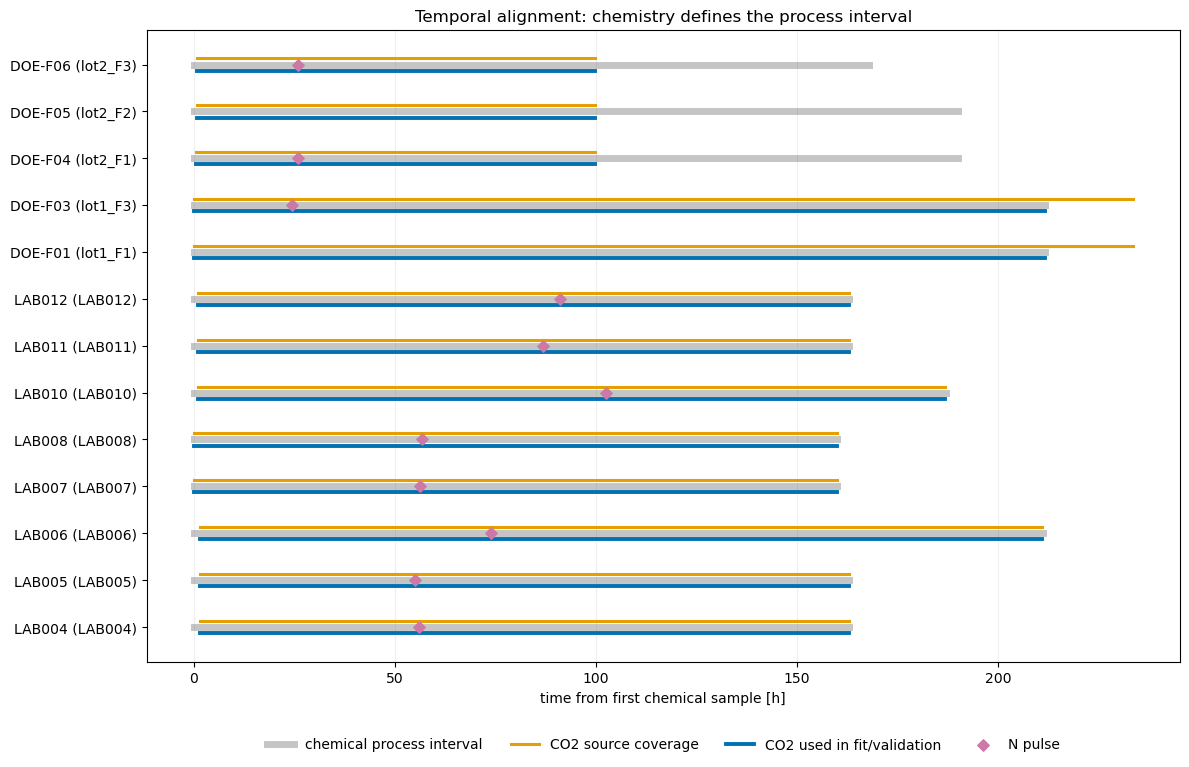

In [2]:
result = analysis.run_analysis(n_starts=5, max_nfev=300, seed=20260812)

display(result["exclusions"])
display(result["inventory"][[
    "matrix", "experiment_code", "batch", "lot", "calibratable", "split",
    "acquisition_channel", "sensor_id", "sensor_zero_offset_sccm",
    "n_co2_hourly", "chemistry_first_h", "chemistry_last_h", "co2_first_h",
    "co2_last_h", "co2_peak_g_l_h", "median_setpoint_c",
    "n_artifacts_replaced", "n_left_censored_hourly", "note"
]])
display(result["natural_nutrient_pulses"][[
    "batch", "calendar_t_h", "density_crossing_t_h", "density_bracket_width_h",
    "model_pulse_time_h", "timing_source", "amount_N_kg_m3",
    "calendar_product", "calendar_dose", "excluded_from_co2_analysis"
]])
fig = analysis.plot_process_timeline_alignment(
    result["inventory"], result["nutrient_pulses"], save=False
)
plt.show()

La separación se hace por fermentación completa. Los pulsos LAB aportan 0.14 kg N m⁻³; el pulso inicial se ignora porque el YAN inicial ya está en t=0. En todos los LAB con cruce disponible, el tiempo del pulso se obtiene por interpolación del cruce de densidad 1040 g/L. Un bracket químico >24 h se conserva, pero se etiqueta como incertidumbre de tiempo. En DOE-F0X se usa el tiempo de proceso existente, sin recalcularlo por densidad ni calendario.

## Filtrado y sensibilidad del sensor

,matrix,experiment_code,batch,acquisition_channel,sensor_id,sensor_zero_offset_sccm,sensor_zero_offset_g_l_h,median_setpoint_c,n_artifacts_replaced,n_sampling_window_transients,n_other_short_transients,negative_signed_fraction,n_left_censored_hourly,n_cold_low_sensitivity_hourly,smoothing_roughness_ratio,smoothing_integral_ratio,smoothing_peak_ratio
0,natural,LAB004,LAB004,F1,1,0.00000,0.000000,18.0,19,19,0,0.102911,65,0,0.304945,1.009568,0.915117
1,natural,LAB005,LAB005,F2,2,0.62066,0.036560,18.0,1,1,0,0.000000,43,0,0.219792,1.004438,0.988852
2,natural,LAB006,LAB006,F3,3,0.52838,0.031124,16.0,2,2,0,0.000000,71,0,0.263213,0.995662,0.962957
3,natural,LAB007,LAB007,F1,1,0.00000,0.000000,18.0,18,15,3,0.046875,60,0,0.403619,1.001061,0.889022
4,natural,LAB008,LAB008,F2,2,0.78048,0.045974,18.0,17,15,2,0.000000,47,0,0.416879,1.005046,0.863164
5,natural,LAB010,LAB010,F1,1,0.00000,0.000000,15.0,0,0,0,0.037273,101,100,0.379791,0.997475,0.993794
6,natural,LAB011,LAB011,F2,2,0.98992,0.058311,21.0,0,0,0,0.000000,85,45,0.416713,0.997368,0.988019
7,natural,LAB012,LAB012,F3,3,0.83948,0.049450,18.0,1,1,0,0.000000,63,52,0.460909,0.999966,0.976676
8,synthetic,DOE-F01,lot1_F1,F1,1,0.03998,0.003089,18.0,51,51,0,0.010236,35,0,0.167762,1.000070,0.880775
9,synthetic,DOE-F03,lot1_F3,F3,3,1.05890,0.081803,20.0,26,26,0,0.000000,57,0,0.208076,1.013734,0.992073


,matrix,batch,experiment_code,lot,acquisition_channel,sensor_id,sensor_assignment_source,zero_method,zero_window_h,zero_quantile,n_zero_candidates,initial_native_q10_sccm,estimated_zero_offset_sccm,estimated_zero_offset_g_l_h,initial_native_median_sccm,initial_corrected_q10_sccm,initial_corrected_median_sccm
0,natural,LAB004,LAB004,natural_2026,F1,1,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,-0.00042,0.00000,0.000000,0.00000,-4.200000e-04,0.00000
1,natural,LAB005,LAB005,natural_2026,F2,2,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,0.62066,0.62066,0.036560,0.72450,4.456071e-17,0.10384
2,natural,LAB006,LAB006,natural_2026,F3,3,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,0.52838,0.52838,0.031124,0.58710,4.453360e-17,0.05872
3,natural,LAB007,LAB007,natural_2026,F1,1,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,-0.00038,0.00000,0.000000,0.00010,-3.800000e-04,0.00010
4,natural,LAB008,LAB008,natural_2026,F2,2,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,0.78048,0.78048,0.045974,0.93975,2.320193e-17,0.15927
5,natural,LAB010,LAB010,natural_2026,F1,1,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,-0.00492,0.00000,0.000000,0.00000,-4.920000e-03,0.00000
6,natural,LAB011,LAB011,natural_2026,F2,2,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,0.98992,0.98992,0.058311,1.00820,-2.218549e-17,0.01828
7,natural,LAB012,LAB012,natural_2026,F3,3,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,0.83948,0.83948,0.049450,0.85040,2.228035e-17,0.01092
8,synthetic,lot1_F1,DOE-F01,MBDOE_lot1,F1,1,explicit DOE mapping; DOE-F06 label 6 is acqui...,initial_12h_q10,12.0,0.1,73,0.03998,0.03998,0.002415,0.15745,-8.673617e-19,0.11747
9,synthetic,lot1_F3,DOE-F03,MBDOE_lot1,F3,3,explicit DOE mapping; DOE-F06 label 6 is acqui...,initial_12h_q10,12.0,0.1,73,1.05890,1.05890,0.063974,1.20635,9.367507e-17,0.14745


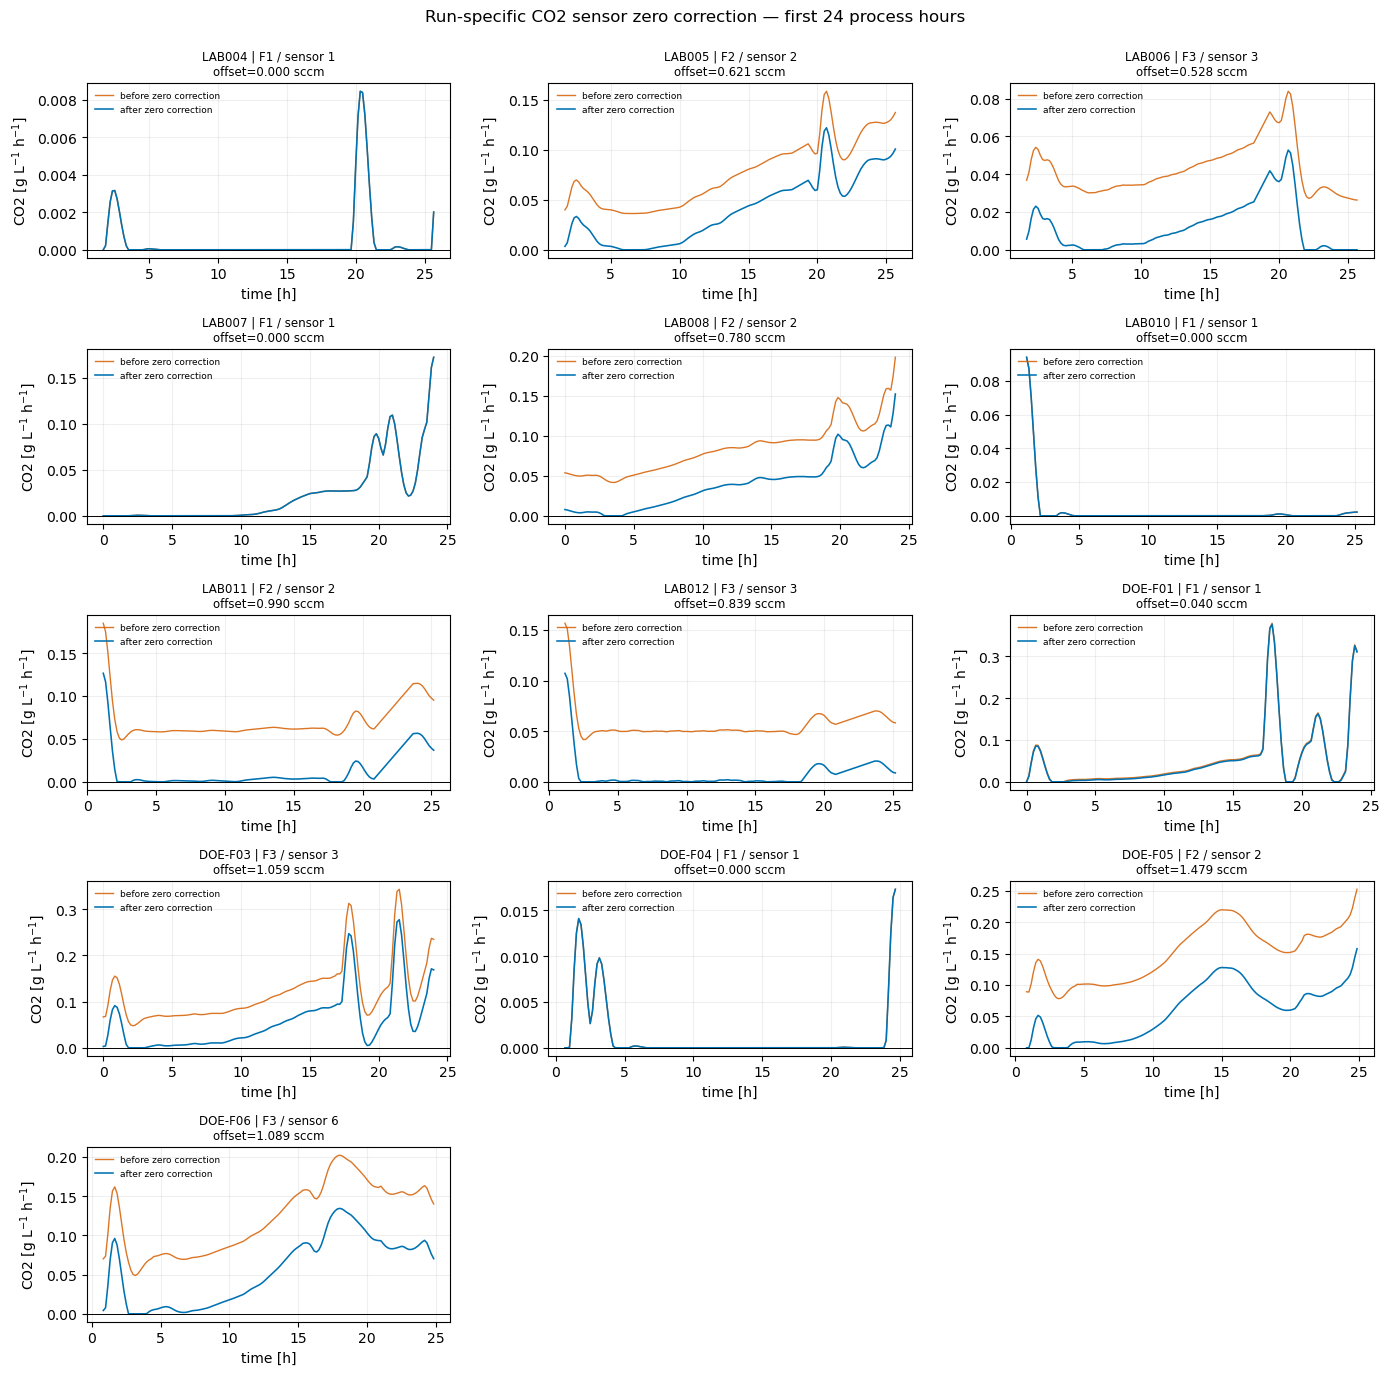

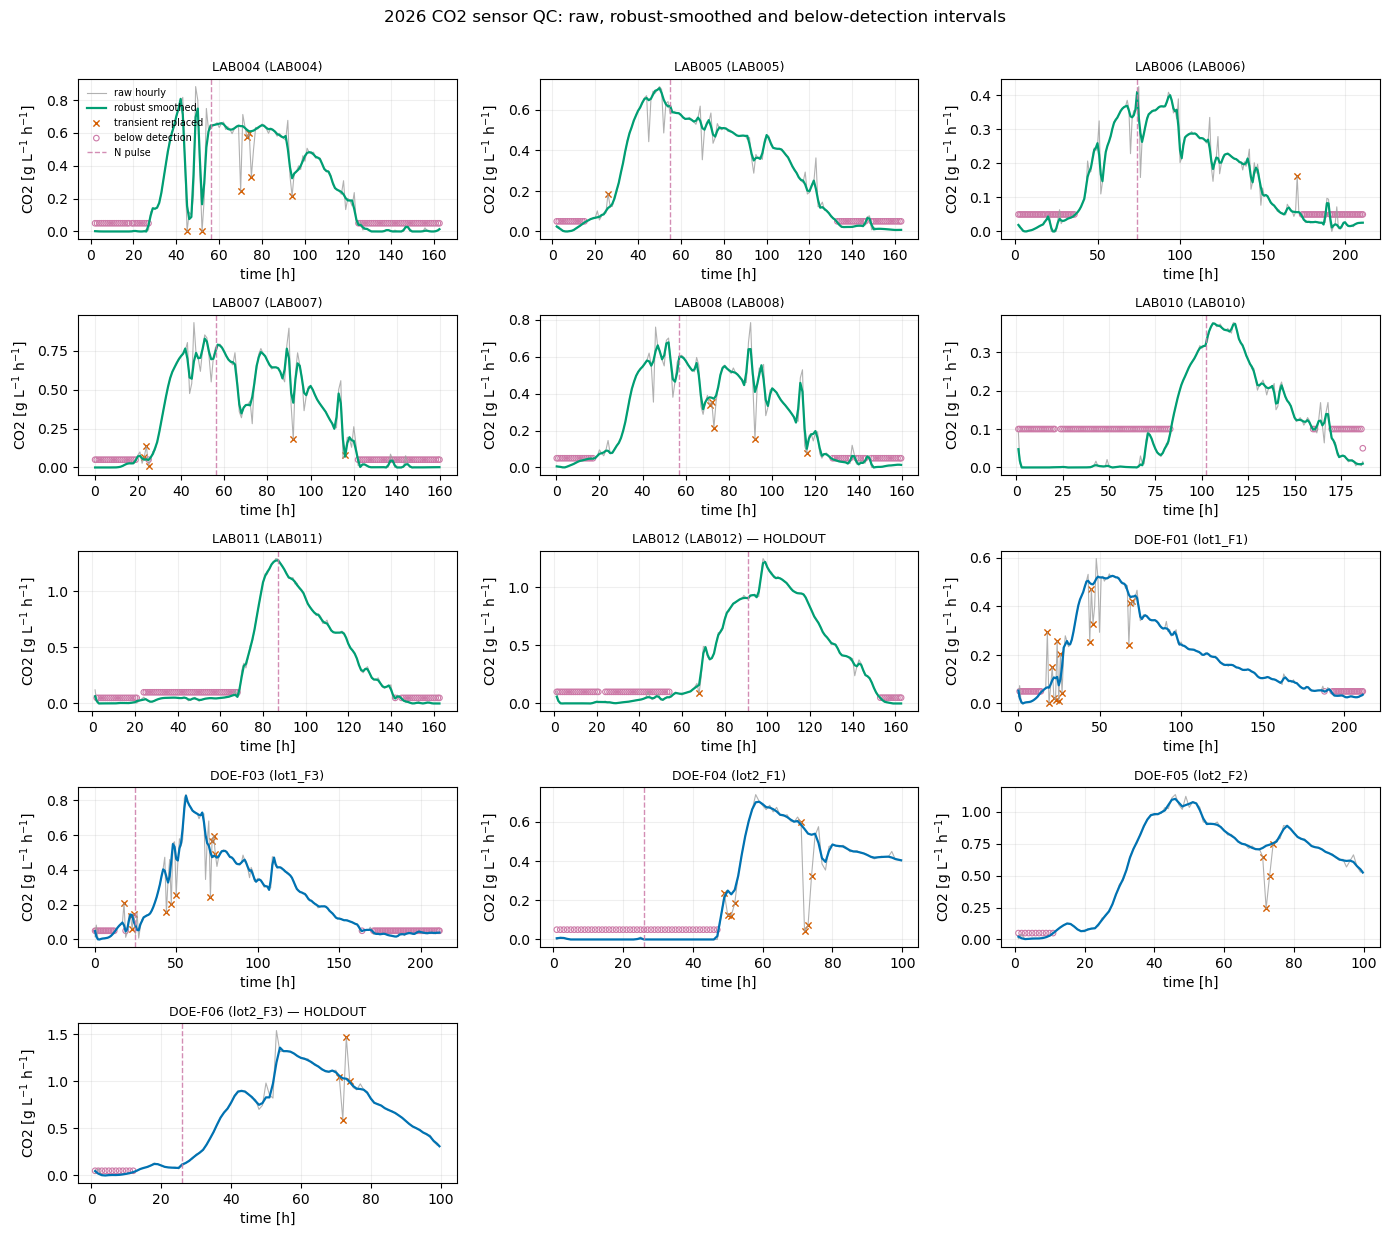

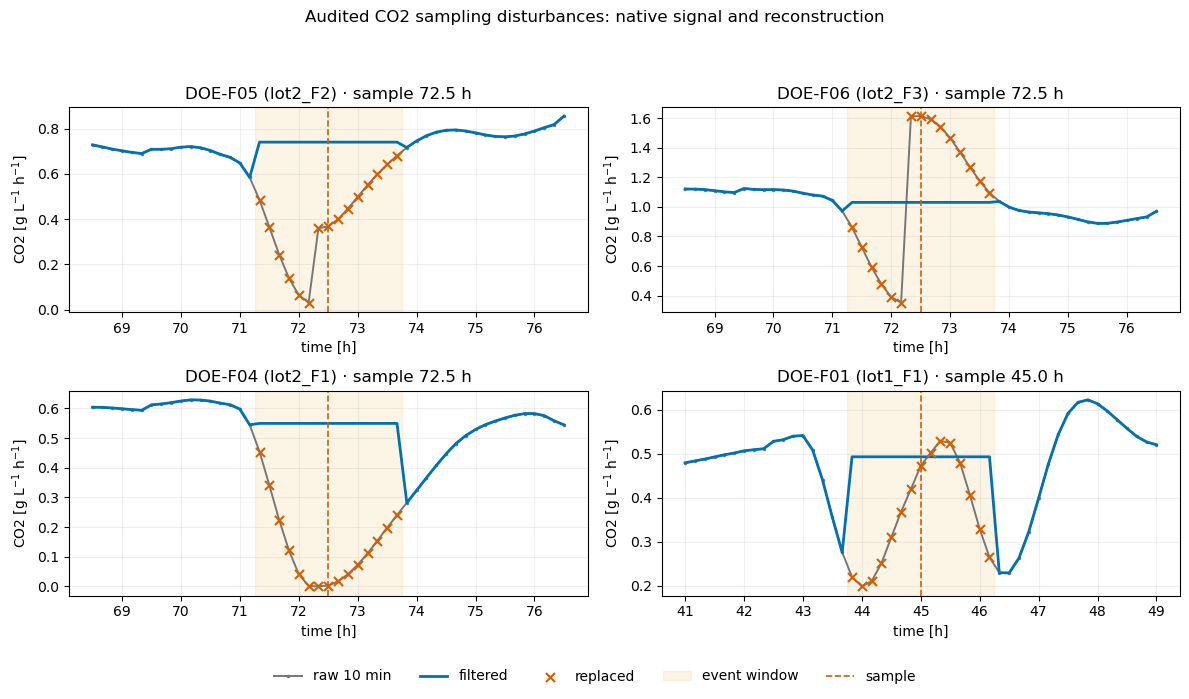

In [3]:
display(result["qc_summary"][[
    "matrix", "experiment_code", "batch", "acquisition_channel", "sensor_id",
    "sensor_zero_offset_sccm", "sensor_zero_offset_g_l_h", "median_setpoint_c",
    "n_artifacts_replaced", "n_sampling_window_transients",
    "n_other_short_transients", "negative_signed_fraction",
    "n_left_censored_hourly", "n_cold_low_sensitivity_hourly",
    "smoothing_roughness_ratio", "smoothing_integral_ratio", "smoothing_peak_ratio"
]])
display(result["sensor_zero_offsets"])
fig = analysis.plot_sensor_zero_correction(
    result["sensor_qc"], result["sensor_zero_offsets"], save=False
)
plt.show()
fig = analysis.plot_data_overview(
    result["observations"], result["nutrient_pulses"], save=False
)
plt.show()
fig = analysis.plot_sensor_filter_examples(
    result["sensor_qc"], result["sampling_schedule"],
    result["nutrient_pulses"], save=False
)
plt.show()

El primer gráfico comprueba la corrección de cero antes de cualquier reconstrucción. El offset se estima por corrida porque los canales muestran deriva entre campañas. Luego, las excursiones asociadas a muestreo se reconstruyen sólo cuando el evento completo está respaldado por niveles pre/post consistentes; se aplica mediana robusta de 3 h y Savitzky–Golay cuadrático de 5 h. Los puntos bajo el umbral local aportan una penalización unilateral si el modelo excede el límite.

## Temperatura y evidencia química de activación

,matrix,batch,temperature_used_min_c,temperature_used_mean_c,temperature_used_max_c,chemical_activity_lower_h,chemical_activity_upper_h,chemical_activity_center_h,initial_o2_saturation_base_mg_l,base_qprod_peak_g_l_h,csat_base_min_g_l,csat_base_max_g_l
0,natural,LAB004,17.7,19.266845,21.4,19.0,26.000000,22.500000,7.648403,0.234717,1.526976,1.839610
1,natural,LAB005,18.0,19.413936,21.4,0.0,19.000000,9.500000,7.497196,0.255925,1.489256,1.829404
2,natural,LAB006,16.0,17.030296,18.4,0.0,19.000000,9.500000,7.929510,0.190537,1.595517,1.988997
3,natural,LAB007,17.4,19.241498,21.1,0.0,16.000000,8.000000,7.497524,0.224490,1.510227,1.955963
4,natural,LAB008,17.4,19.195164,21.1,0.0,16.000000,8.000000,7.542804,0.233491,1.505889,1.791119
5,natural,LAB010,14.9,15.442991,16.5,0.0,72.000000,36.000000,8.146563,0.262454,1.662163,2.219580
6,natural,LAB011,14.9,18.842113,21.4,19.0,67.000000,43.000000,7.605382,0.308738,1.519073,1.975653
7,natural,LAB012,15.0,18.390505,21.2,0.0,48.000000,24.000000,8.150655,0.260424,1.649435,1.862792
8,synthetic,lot1_F1,17.6,18.107438,18.7,0.0,17.000000,8.500000,7.043979,0.347706,1.338996,1.862974
9,synthetic,lot1_F3,16.6,20.039876,23.0,0.0,17.000000,8.500000,7.792047,0.245907,1.431235,1.753645


,matrix,batch,experiment_code,n_temperature_comparisons,model_minus_sensor_bias_c,model_sensor_mae_c,model_sensor_rmse_c,model_sensor_max_abs_c
0,natural,LAB004,LAB004,162,0.006121,0.098508,0.142957,0.466667
1,natural,LAB005,LAB005,162,0.001800,0.038632,0.066050,0.250000
2,natural,LAB006,LAB006,209,0.022089,0.075518,0.131357,0.616667
3,natural,LAB007,LAB007,161,-0.005771,0.107531,0.259512,2.133333
4,natural,LAB008,LAB008,161,0.002277,0.058799,0.147161,1.500000
5,natural,LAB010,LAB010,184,0.017346,0.063089,0.095622,0.333333
6,natural,LAB011,LAB011,160,0.015964,0.081172,0.193215,1.866667
7,natural,LAB012,LAB012,160,0.019010,0.066146,0.148282,1.300000
8,synthetic,lot1_F1,DOE-F01,213,0.015258,0.261268,0.330510,0.800000
9,synthetic,lot1_F3,DOE-F03,213,-0.014554,0.093427,0.164445,0.700000


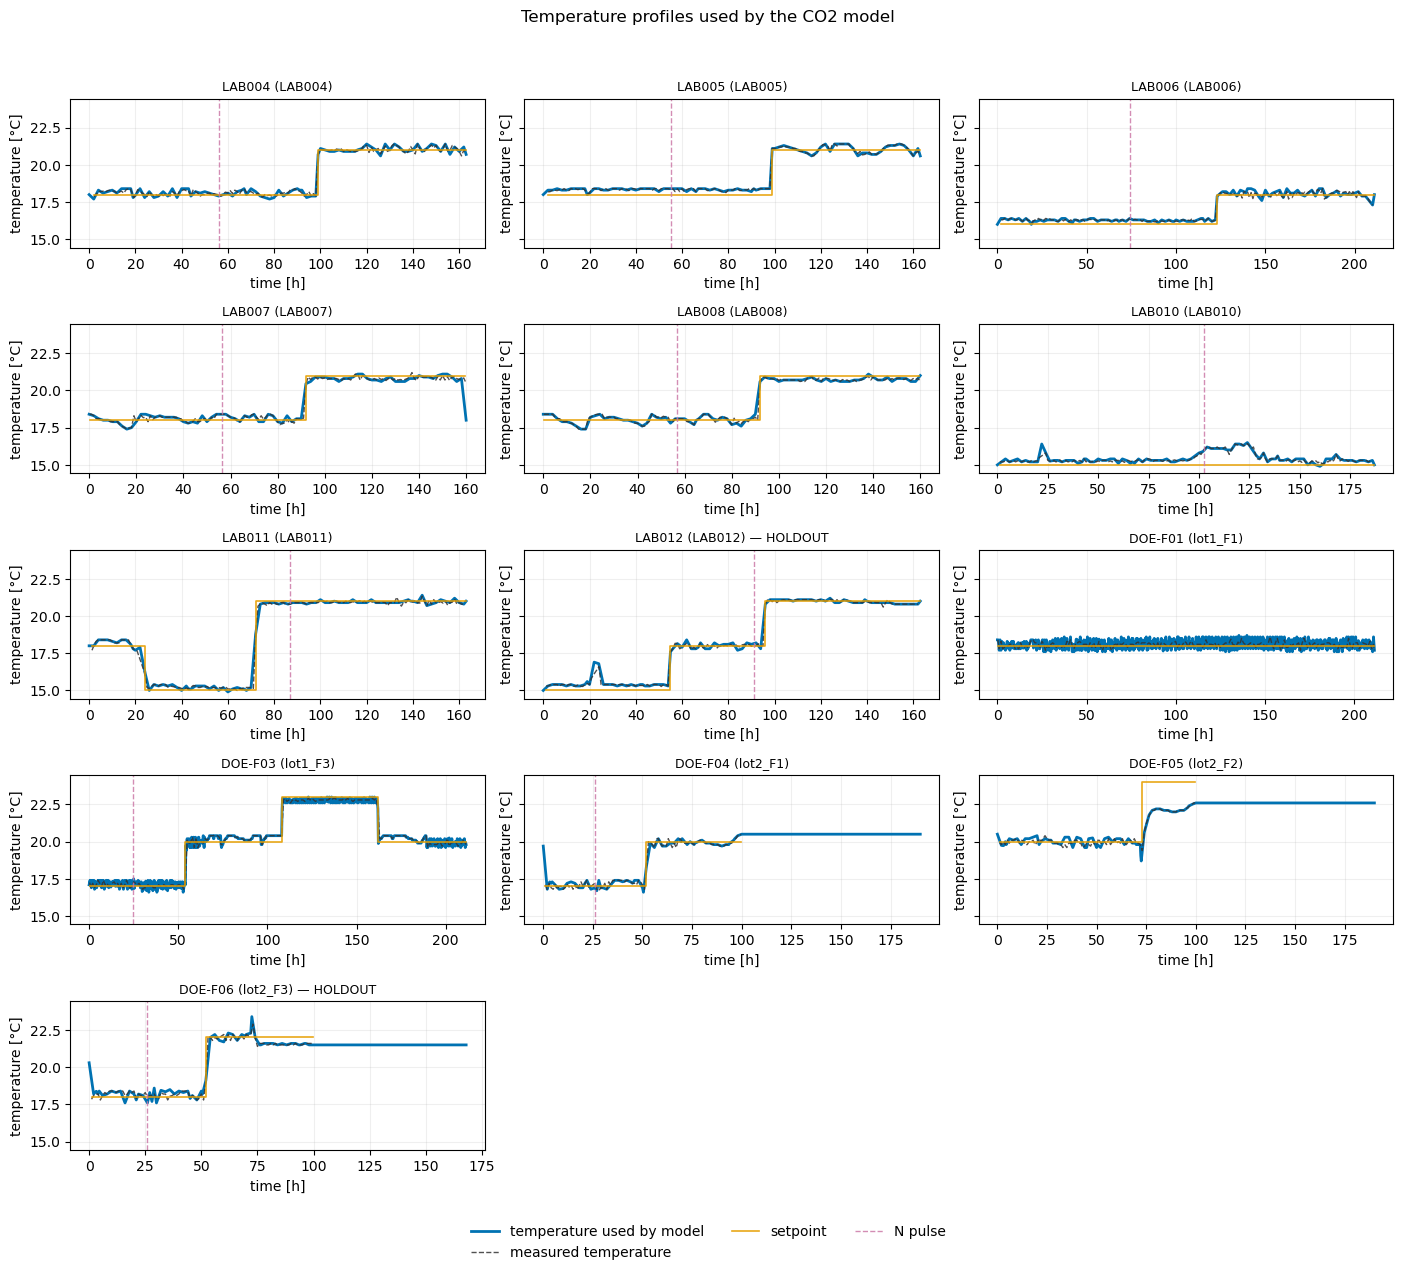

In [4]:
display(result["driver_diagnostics"][[
    "matrix", "batch", "temperature_used_min_c", "temperature_used_mean_c",
    "temperature_used_max_c", "chemical_activity_lower_h",
    "chemical_activity_upper_h", "chemical_activity_center_h",
    "initial_o2_saturation_base_mg_l", "base_qprod_peak_g_l_h",
    "csat_base_min_g_l", "csat_base_max_g_l"
]])
display(result["temperature_alignment"])
fig = analysis.plot_temperature_profiles(
    result["observations"], result["temperature_inputs"],
    result["nutrient_pulses"], save=False
)
plt.show()

La temperatura medida/reconstruida entra tanto a los drivers cinéticos como a la solubilidad de CO₂; el setpoint queda como referencia. La tabla permite verificar, lote por lote, el intervalo químico que condiciona el encendido de la fuente.

## Calibración por matriz

,calibration_matrix,parameter,estimate,lower_bound,upper_bound,active_bound,relative_bound_distance
0,synthetic,kCO2_release_h,3.883700,0.03,25.00,False,2.768725e-01
1,synthetic,CO2sat_scale,0.425409,0.35,2.50,False,9.924006e-02
2,synthetic,O2_qmax_mg_gdw_h,0.150164,0.15,6.00,True,2.956747e-04
3,synthetic,O2_initial_scale,0.380416,0.05,1.50,False,4.033740e-01
4,synthetic,pulse_t_rise_h,36.500009,1.00,72.00,False,1.588512e-01
5,synthetic,pulse_activity_gain,1.233338,0.25,4.00,False,4.243579e-01
6,synthetic,chem_activation_start_fraction,0.010004,0.01,0.95,True,8.834046e-05
7,synthetic,chem_activation_duration_fraction,0.350000,0.35,2.00,True,1.204413e-09
8,synthetic,matrix_gain,2.126556,0.10,20.00,False,4.230076e-01
9,natural,kCO2_release_h,0.424588,0.03,25.00,False,3.940151e-01


,matrix,success,nfev,wsse_equal_batch,kCO2_release_h,CO2sat_scale,O2_qmax_mg_gdw_h,O2_initial_scale,pulse_t_rise_h,pulse_activity_gain,chem_activation_start_fraction,chem_activation_duration_fraction,matrix_gain
0,natural,True,43,27.952096,0.424588,0.351390,0.150000,0.195400,64.658704,0.250000,0.735057,1.06391,3.115757
1,synthetic,True,89,19.515601,3.883700,0.425409,0.150164,0.380416,36.500009,1.233338,0.010004,0.35000,2.126556


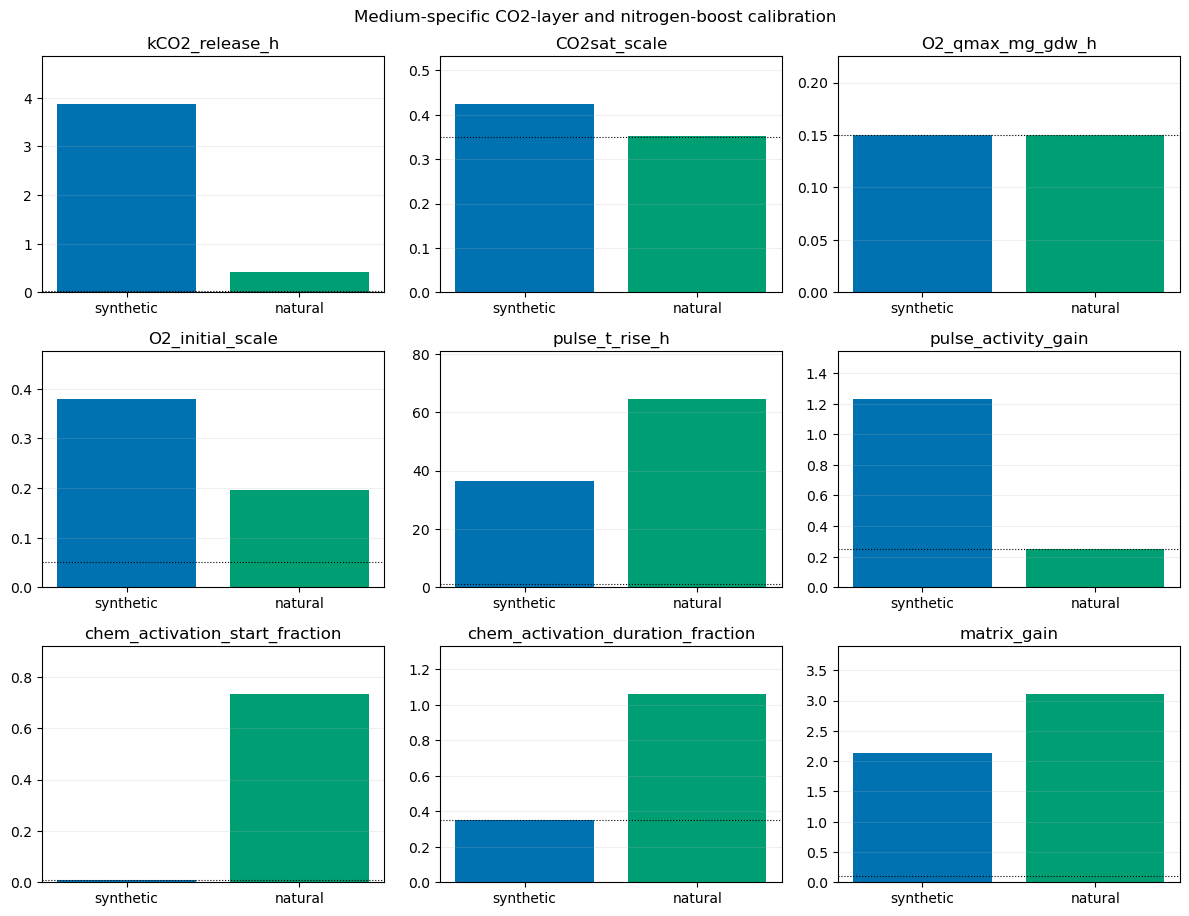

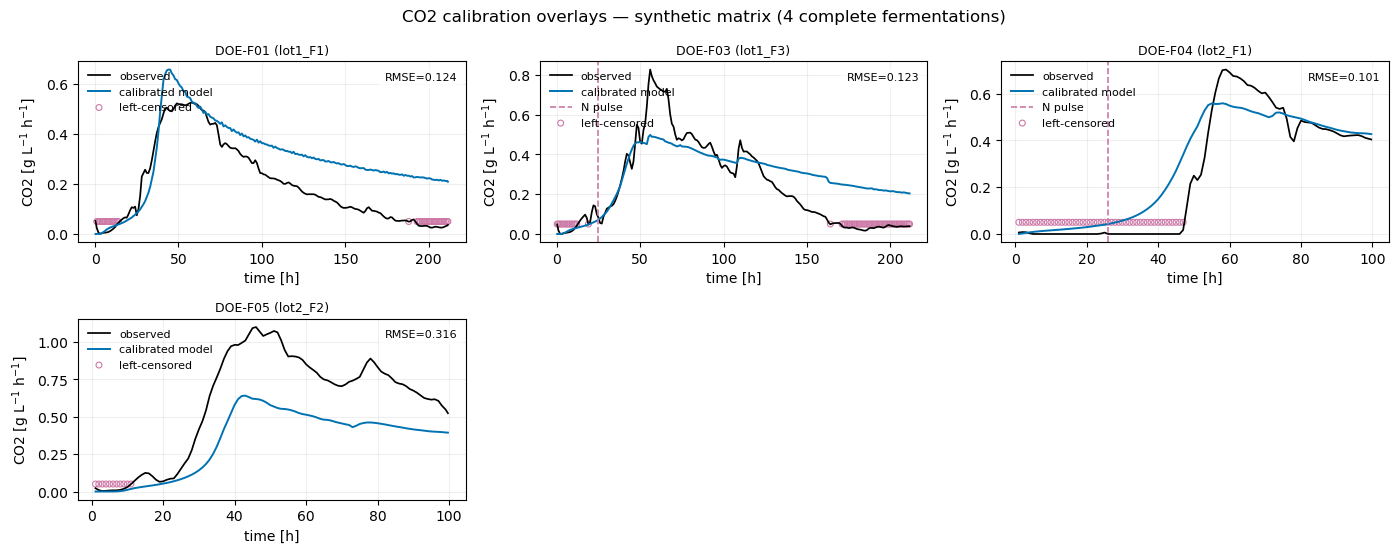

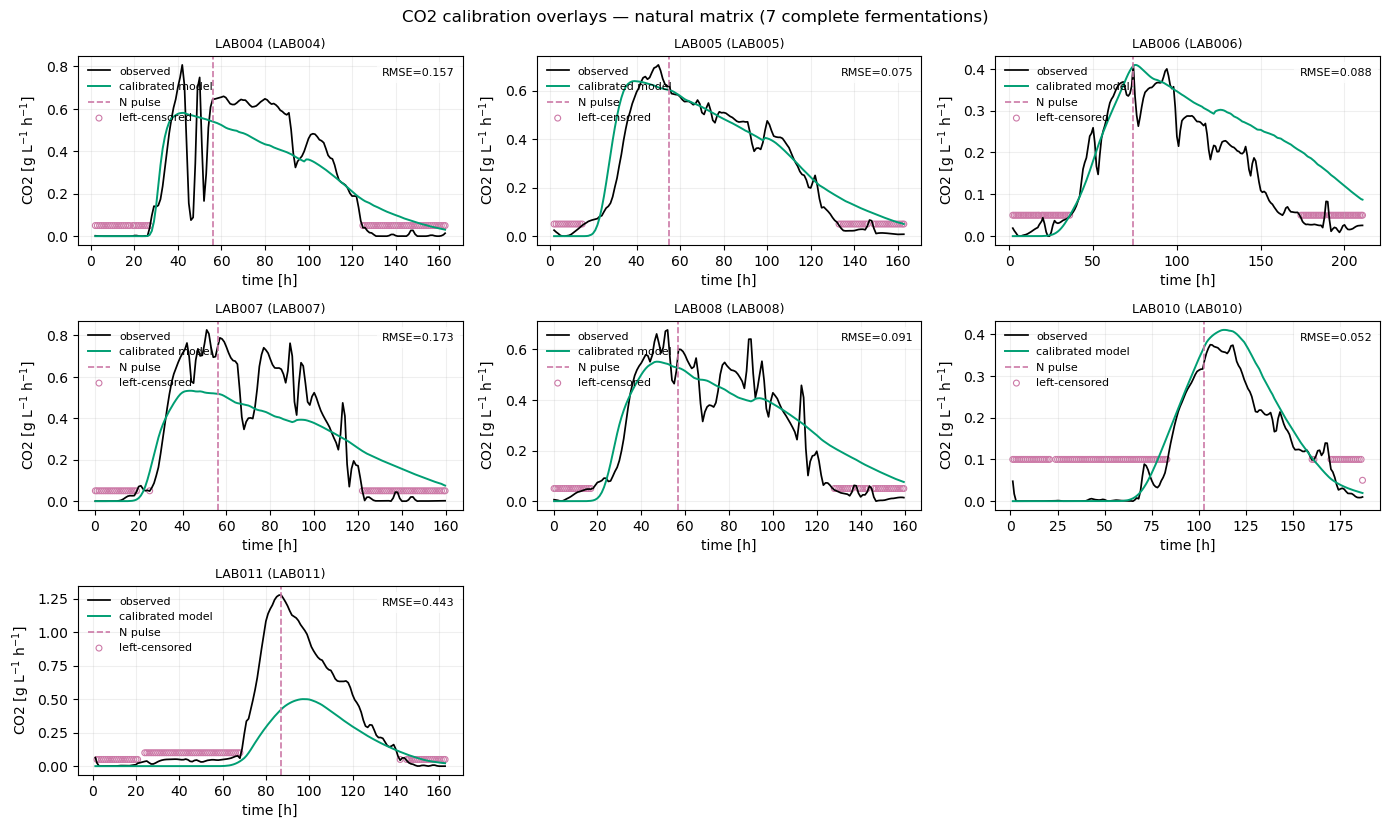

In [5]:
display(result["fit_parameters"])
best_starts = (
    result["fit_starts"].sort_values("wsse_equal_batch")
    .groupby("matrix", as_index=False).first()
)
display(best_starts[[
    "matrix", "success", "nfev", "wsse_equal_batch", "kCO2_release_h",
    "CO2sat_scale", "O2_qmax_mg_gdw_h", "O2_initial_scale",
    "pulse_t_rise_h", "pulse_activity_gain",
    "chem_activation_start_fraction", "chem_activation_duration_fraction",
    "matrix_gain"
]])
fig = analysis.plot_parameter_comparison(result["fit_parameters"], save=False)
plt.show()
for matrix in ("synthetic", "natural"):
    fig = analysis.plot_calibration_overlays(result["predictions"], matrix, save=False)
    plt.show()

`active_bound=True` indica que el dato sólo acota el parámetro en el borde permitido. Debe leerse como tensión estructural o falta de identificabilidad, no como una estimación interior resuelta. `chem_activation_start_fraction` ubica el inicio dentro del bracket químico y `chem_activation_duration_fraction` escala la duración por el ancho de ese bracket. `pulse_activity_gain=1` significa ausencia de modulación sobre la actividad preexistente; >1 es boost y <1 es atenuación.

## Estimabilidad de inicio y duración

,matrix,n_residuals,n_shape_parameters,effective_rank,condition_number_log_parameter_jacobian,smallest_singular_value,largest_singular_value,residual_variance_scale,interpretation
0,synthetic,632,8,8,2.924468e+07,2.660833e-07,7.781521,0.031275,ill_conditioned
1,natural,1216,8,8,1.298599e+02,7.868365e-02,10.217854,0.023139,moderate_or_better


,matrix,parameter_1,parameter_2,local_log_parameter_correlation
126,natural,chem_activation_duration_fraction,chem_activation_start_fraction,-0.917884
123,natural,chem_activation_duration_fraction,O2_initial_scale,-0.305851
125,natural,chem_activation_duration_fraction,pulse_activity_gain,-0.165916
122,natural,chem_activation_duration_fraction,O2_qmax_mg_gdw_h,-0.154144
124,natural,chem_activation_duration_fraction,pulse_t_rise_h,0.017143
120,natural,chem_activation_duration_fraction,kCO2_release_h,0.518135
121,natural,chem_activation_duration_fraction,CO2sat_scale,0.565405
127,natural,chem_activation_duration_fraction,chem_activation_duration_fraction,1.000000
119,natural,chem_activation_start_fraction,chem_activation_duration_fraction,-0.917884
113,natural,chem_activation_start_fraction,CO2sat_scale,-0.669927


,matrix,parameter,full_fit_estimate,loo_min,loo_median,loo_max,loo_range,loo_relative_range_to_full,n_omissions,n_at_lower_bound,n_at_upper_bound
0,natural,chem_activation_start_fraction,0.735057,0.735102,0.762488,0.826589,9.148752e-02,1.244632e-01,7,0,0
1,natural,chem_activation_duration_fraction,1.063910,0.371317,0.994898,1.104831,7.335145e-01,6.894518e-01,7,0,0
2,synthetic,chem_activation_start_fraction,0.010004,0.010000,0.010001,0.010002,2.019286e-06,2.018473e-04,4,4,0
3,synthetic,chem_activation_duration_fraction,0.350000,0.350000,0.350000,0.350000,3.685359e-10,1.052960e-09,4,4,0


,matrix,omitted_batch,success,nfev,chem_activation_start_fraction,chem_activation_duration_fraction
0,synthetic,lot1_F1,True,19,0.010000,0.350000
1,synthetic,lot1_F3,True,29,0.010001,0.350000
2,synthetic,lot2_F1,True,32,0.010002,0.350000
3,synthetic,lot2_F2,True,35,0.010001,0.350000
4,natural,LAB004,True,12,0.762488,0.994898
5,natural,LAB005,True,26,0.819262,0.866620
6,natural,LAB006,True,19,0.735102,1.064119
7,natural,LAB007,True,19,0.766871,0.922985
8,natural,LAB008,True,20,0.737969,1.027484
9,natural,LAB010,True,42,0.826589,0.371317


,matrix,profiled_parameter,fixed_value,wsse_equal_batch,success,nfev,full_fit_estimate,delta_wsse,relative_wsse_increase
0,natural,chem_activation_duration_fraction,0.350000,28.764798,True,36,1.063910,9.845729e-01,3.544150e-02
1,natural,chem_activation_duration_fraction,0.467981,28.076144,True,24,1.063910,2.959195e-01,1.065217e-02
2,natural,chem_activation_duration_fraction,0.625732,27.782747,True,30,1.063910,2.522347e-03,9.079650e-05
3,natural,chem_activation_duration_fraction,0.836660,27.780225,True,27,1.063910,0.000000e+00,0.000000e+00
4,natural,chem_activation_duration_fraction,1.063910,27.952096,True,9,1.063910,1.718712e-01,6.186818e-03
5,natural,chem_activation_duration_fraction,1.118689,28.208017,True,15,1.063910,4.277926e-01,1.539918e-02
6,natural,chem_activation_duration_fraction,1.495787,28.959134,True,30,1.063910,1.178909e+00,4.243698e-02
7,natural,chem_activation_duration_fraction,2.000000,30.187885,True,26,1.063910,2.407661e+00,8.666815e-02
8,natural,chem_activation_start_fraction,0.010000,39.198015,True,32,0.735057,1.124592e+01,4.023283e-01
9,natural,chem_activation_start_fraction,0.166667,33.093774,True,30,0.735057,5.141678e+00,1.839461e-01


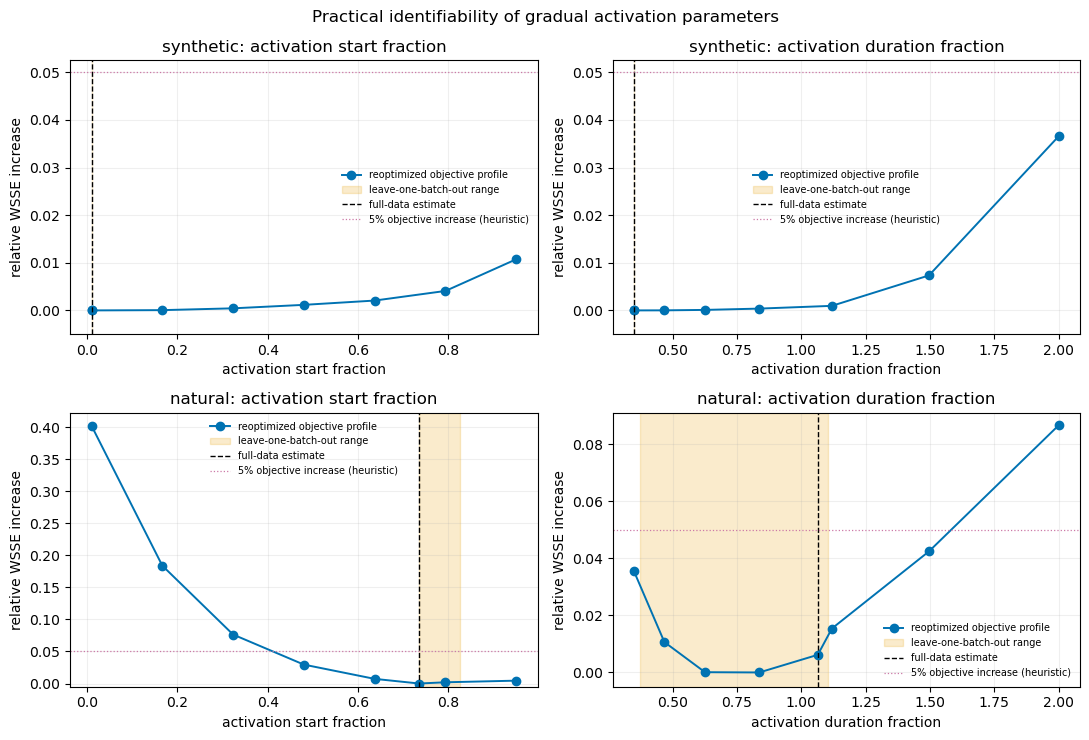

In [6]:
display(result["jacobian_identifiability"])
display(
    result["local_parameter_correlations"].query(
        "parameter_1 in ['chem_activation_start_fraction', 'chem_activation_duration_fraction']"
    )[["matrix", "parameter_1", "parameter_2", "local_log_parameter_correlation"]]
    .sort_values(["matrix", "parameter_1", "local_log_parameter_correlation"])
)
display(result["loo_activation_summary"])
display(result["loo_activation_estimates"][[
    "matrix", "omitted_batch", "success", "nfev",
    "chem_activation_start_fraction", "chem_activation_duration_fraction"
]])
display(result["activation_profiles"])
fig = analysis.plot_activation_identifiability(
    result["activation_profiles"], result["loo_activation_summary"], save=False
)
plt.show()

El Jacobiano evalúa sensibilidad local en log-parámetros; un número de condición alto indica direcciones compensables. Los perfiles fijan uno de los dos parámetros y reoptimizan todos los demás. La franja naranjo muestra cuánto cambia la estimación al retirar una fermentación completa. La línea horizontal de 5 % es sólo un umbral descriptivo de sensibilidad del objetivo, no un intervalo de confianza de verosimilitud.

## ¿Se corrigió la cola inicial?

,target_matrix,experiment_code,batch,median_setpoint_c,cold_operation,chemical_activity_lower_h,chemical_activity_upper_h,source_10pct_peak_onset_h,o2_below_anaerobic_halfpoint_h,observed_onset_h,predicted_onset_h,onset_delay_h,O2_qmax_mg_gdw_h,O2_initial_scale,n_pulse_time_h,pulse_t_rise_h,pulse_activity_gain,chem_activation_start_fraction,chem_activation_duration_fraction,pulse_utilization_complete_h,observed_postpulse_peak_h,predicted_postpulse_peak_h,postpulse_peak_delay_h
8,synthetic,DOE-F01,lot1_F1,18.0,False,0.0,17.000000,20.75,36.75,16.399541,20.521471,4.121930,0.150164,0.380416,NaN,36.500009,1.233338,0.010004,0.35000,NaN,NaN,NaN,NaN
9,synthetic,DOE-F03,lot1_F3,20.0,False,0.0,17.000000,18.00,38.25,20.640551,27.760570,7.120019,0.150164,0.380416,24.500000,36.500009,1.233338,0.010004,0.35000,61.000009,56.0,56.0,0.0
10,synthetic,DOE-F04,lot2_F1,17.0,False,0.0,3.174722,28.25,45.00,47.547195,32.566358,-14.980837,0.150164,0.380416,26.000000,36.500009,1.233338,0.010004,0.35000,62.500009,59.0,58.0,-1.0
11,synthetic,DOE-F05,lot2_F2,20.0,False,4.5,21.000000,21.00,36.00,24.057329,28.498776,4.441447,0.150164,0.380416,NaN,36.500009,1.233338,0.010004,0.35000,NaN,NaN,NaN,NaN
12,synthetic,DOE-F06,lot2_F3,18.0,False,4.5,21.000000,33.25,42.25,27.509842,36.311062,8.801219,0.150164,0.380416,26.000000,36.500009,1.233338,0.010004,0.35000,62.500009,54.0,54.0,0.0
13,natural,LAB004,LAB004,18.0,False,19.0,26.000000,25.75,12.50,27.735273,29.163030,1.427757,0.150000,0.195400,56.091667,64.658704,0.250000,0.735057,1.06391,120.750370,61.0,57.0,-4.0
14,natural,LAB005,LAB005,18.0,False,0.0,19.000000,18.50,10.00,22.576040,23.020735,0.444695,0.150000,0.195400,55.086614,64.658704,0.250000,0.735057,1.06391,119.745318,56.0,56.0,0.0
15,natural,LAB006,LAB006,16.0,False,0.0,19.000000,31.50,35.50,36.543760,36.181485,-0.362275,0.150000,0.195400,74.000000,64.658704,0.250000,0.735057,1.06391,138.658704,74.0,75.0,1.0
16,natural,LAB007,LAB007,18.0,False,0.0,16.000000,18.25,15.25,26.797300,23.353409,-3.443891,0.150000,0.195400,56.246154,64.658704,0.250000,0.735057,1.06391,120.904858,57.0,57.0,0.0
17,natural,LAB008,LAB008,18.0,False,0.0,16.000000,18.75,17.00,20.661926,23.810561,3.148634,0.150000,0.195400,56.750000,64.658704,0.250000,0.735057,1.06391,121.408704,90.0,57.0,-33.0


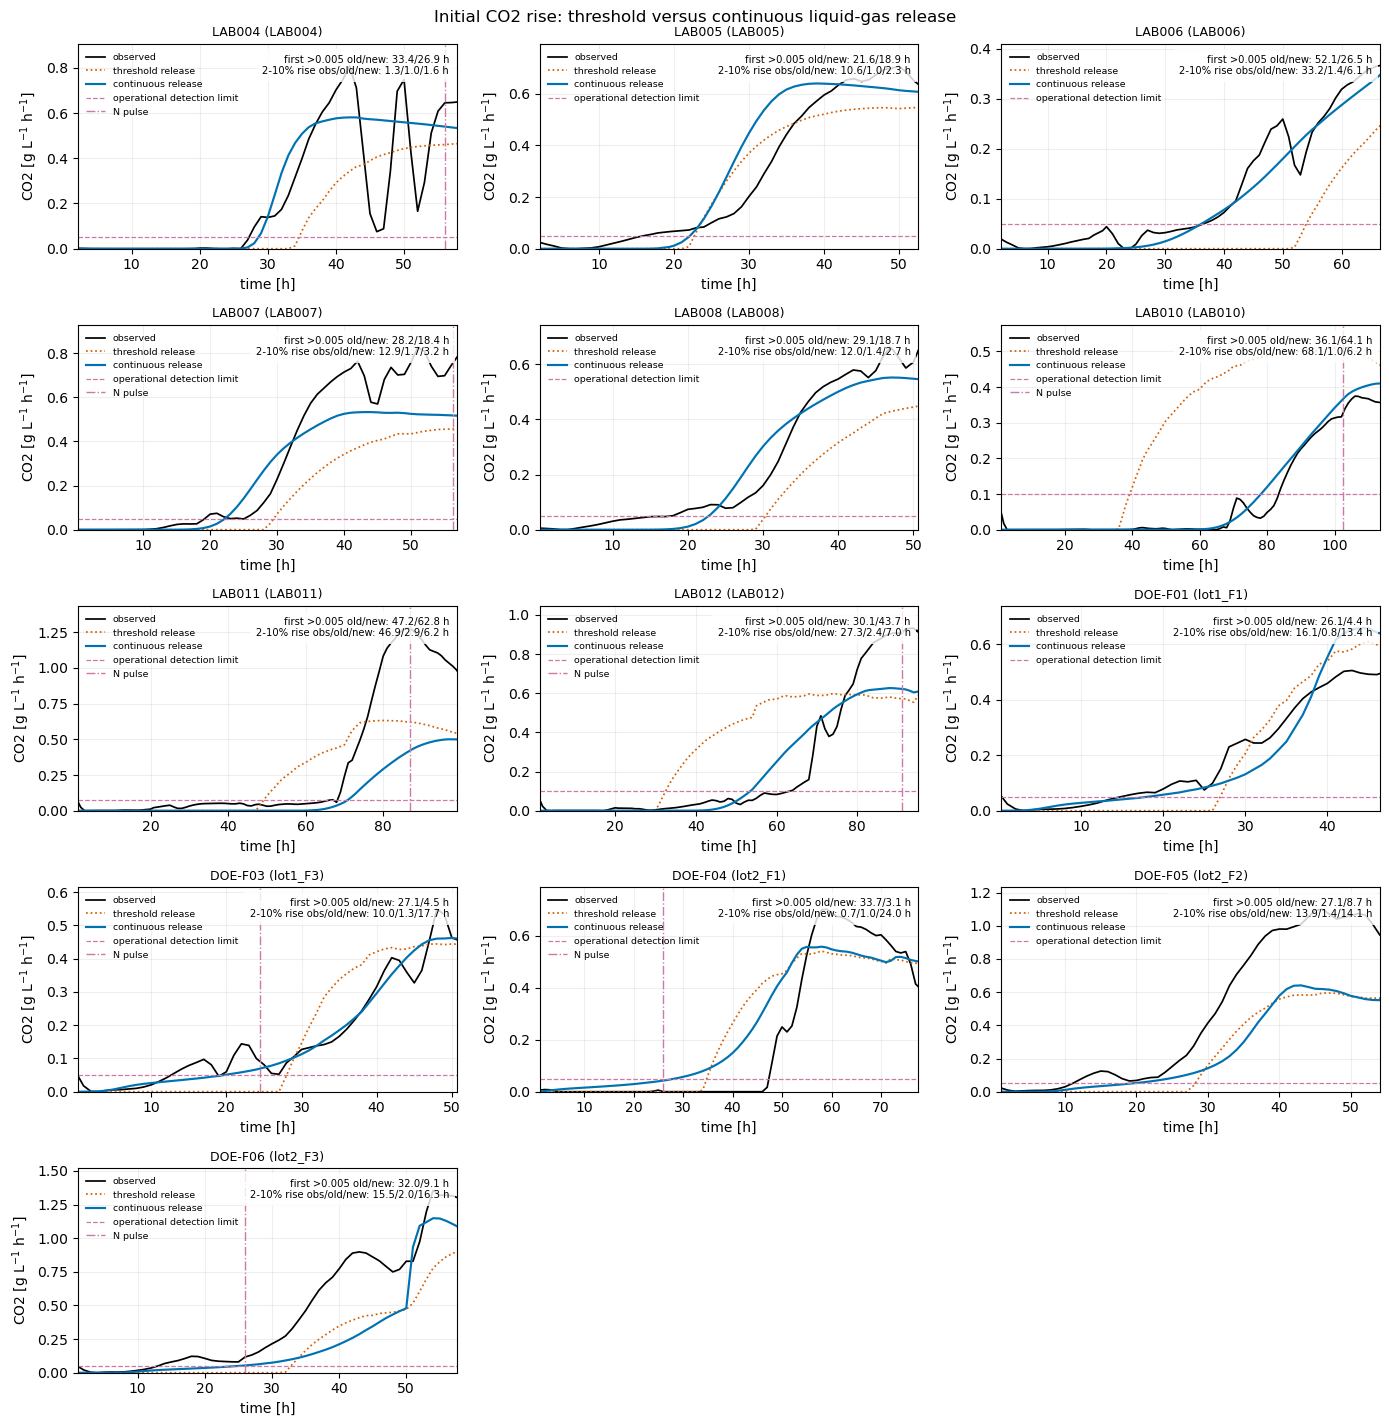

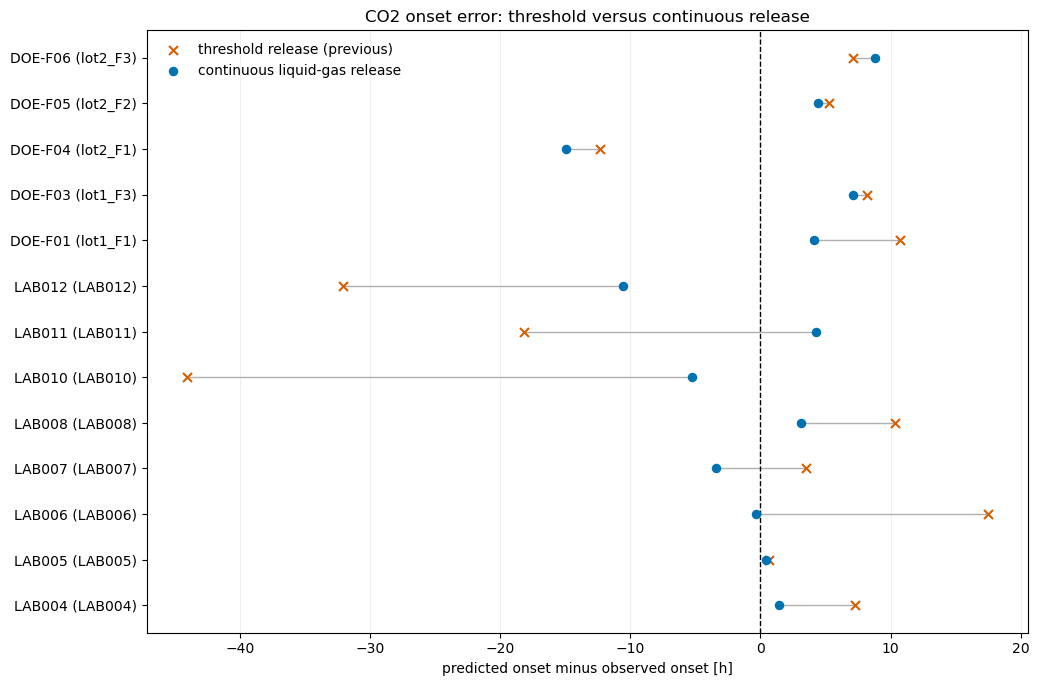

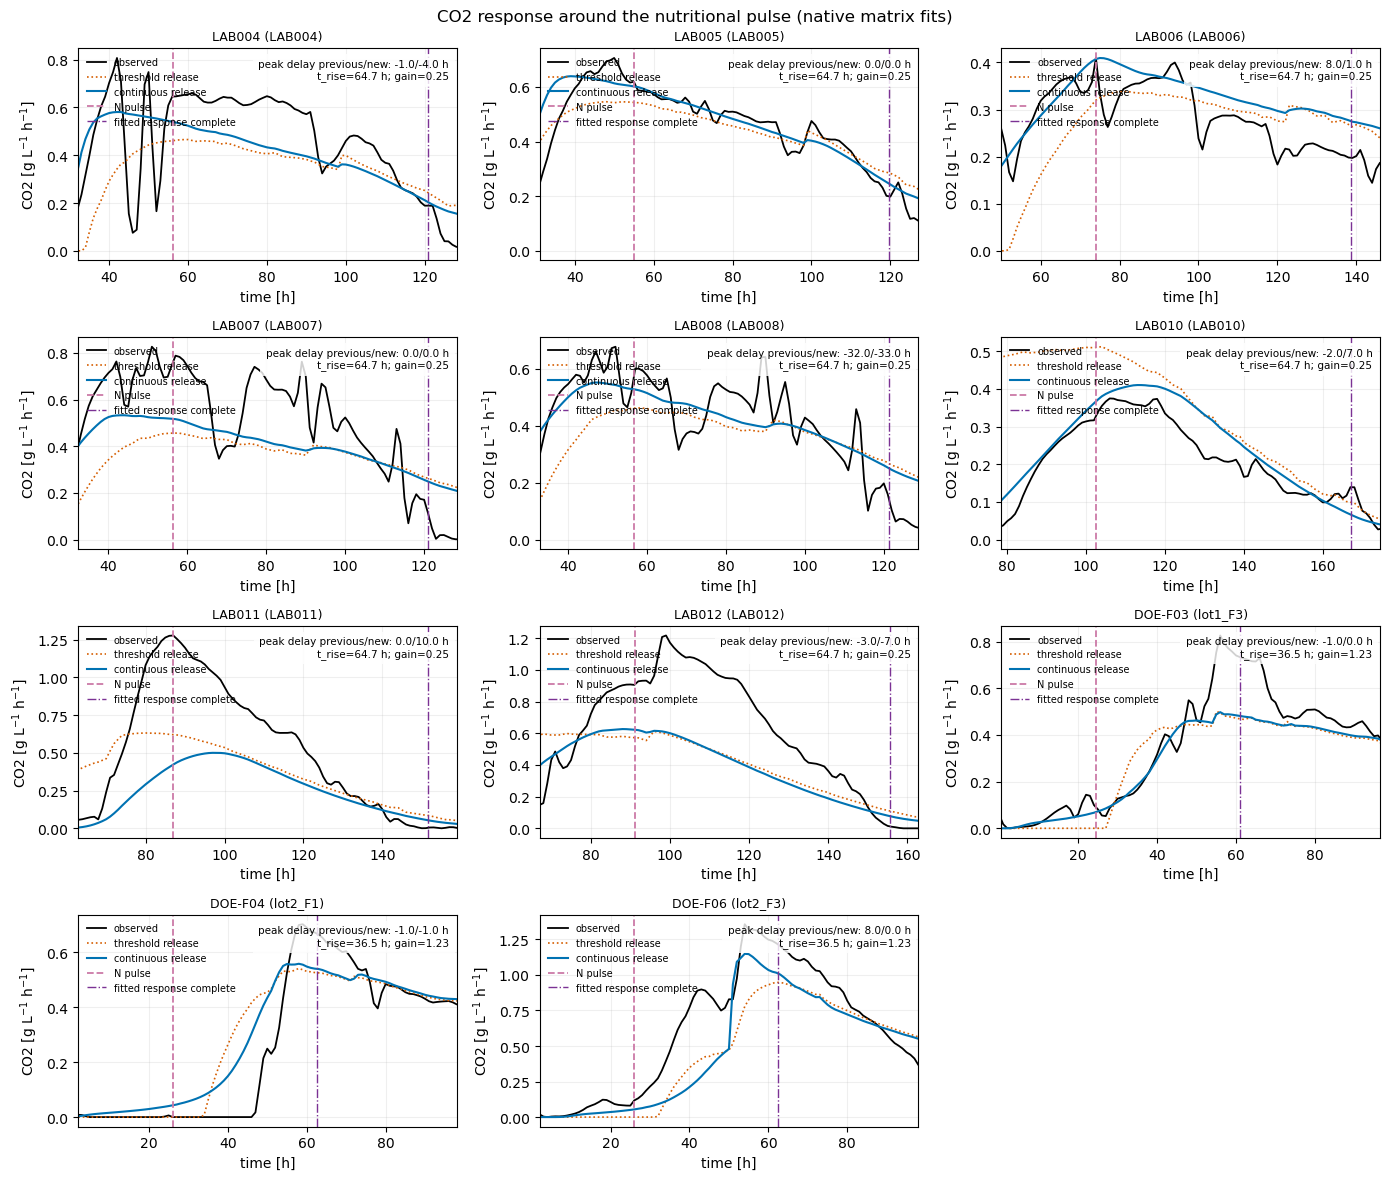

In [7]:
native_transition = result["source_transition_diagnostics"].query("native_matrix_fit").copy()
display(native_transition[[
    "target_matrix", "experiment_code", "batch", "median_setpoint_c",
    "cold_operation", "chemical_activity_lower_h", "chemical_activity_upper_h",
    "source_10pct_peak_onset_h", "o2_below_anaerobic_halfpoint_h",
    "observed_onset_h", "predicted_onset_h", "onset_delay_h",
    "O2_qmax_mg_gdw_h", "O2_initial_scale", "n_pulse_time_h",
    "pulse_t_rise_h", "pulse_activity_gain",
    "chem_activation_start_fraction", "chem_activation_duration_fraction",
    "pulse_utilization_complete_h",
    "observed_postpulse_peak_h", "predicted_postpulse_peak_h",
    "postpulse_peak_delay_h"
]])
fig = analysis.plot_initial_release_comparison(
    result["predictions"], result["previous_predictions"],
    result["batch_metrics"], result["previous_batch_metrics"], save=False
)
plt.show()
fig = analysis.plot_onset_model_comparison(
    result["batch_metrics"], result["previous_batch_metrics"], save=False
)
plt.show()
fig = analysis.plot_pulse_response_comparison(
    result["predictions"], result["previous_predictions"],
    result["batch_metrics"], result["previous_batch_metrics"],
    result["source_transition_diagnostics"], save=False
)
plt.show()

El primer gráfico es el control visual principal: amplía el inicio de cada lote y compara liberación por umbral (naranjo) con liberación continua (azul). La línea horizontal marca 0.005 g L⁻¹ h⁻¹; el texto cuantifica la primera emisión y la duración 2–10 %. El segundo resume el error de inicio. El tercero amplía cada lote pulsado: línea magenta = adición; línea morada = término de la disponibilidad gradual estimada.

## Validación retenida y transferencia cruzada

,scenario,calibration_matrix,target_matrix,experiment_code,batch,n,n_total,n_left_censored,rmse_g_l_h,nrmse_peak,bias_g_l_h,correlation,r2,integral_ratio_pred_over_observed_lower_bound,observed_onset_h,predicted_onset_h,onset_delay_h,predicted_first_emission_0p005_h,observed_visual_rise_duration_h,predicted_visual_rise_duration_h,visual_rise_duration_error_h,pulse_time_h,observed_postpulse_peak_h,predicted_postpulse_peak_h,postpulse_peak_delay_h
0,cross_matrix_holdout,synthetic,natural,LAB012,LAB012,98,161,63,0.382957,0.314682,-0.196445,0.391021,-0.199708,0.989880,65.156714,14.756722,-50.399992,6.276073,27.311566,5.156483,-22.155083,91.041739,99.0,102.0,3.0
1,within_matrix_holdout,natural,natural,LAB012,LAB012,98,161,63,0.318335,0.261581,-0.207234,0.776992,0.171016,0.668023,65.156714,54.596645,-10.560070,43.708807,27.311566,6.963335,-20.348230,91.041739,99.0,92.0,-7.0
2,cross_matrix_holdout,natural,synthetic,DOE-F06,lot2_F3,88,100,12,0.325977,0.240235,-0.287485,0.963342,0.314389,0.574874,27.509842,30.380297,2.870455,23.364577,15.479194,3.715638,-11.763556,26.000000,54.0,56.0,2.0
3,within_matrix_holdout,synthetic,synthetic,DOE-F06,lot2_F3,88,100,12,0.244314,0.180052,-0.152360,0.876565,0.614877,0.770099,27.509842,36.311062,8.801219,9.141976,15.479194,16.298815,0.819621,26.000000,54.0,54.0,0.0


,scenario,calibration_matrix,target_matrix,batch,experiment_code,rmse_g_l_h_threshold_release,nrmse_peak_threshold_release,correlation_threshold_release,r2_threshold_release,integral_ratio_pred_over_observed_lower_bound_threshold_release,observed_onset_h_threshold_release,predicted_onset_h_threshold_release,onset_delay_h_threshold_release,predicted_first_emission_0p005_h_threshold_release,observed_visual_rise_duration_h_threshold_release,predicted_visual_rise_duration_h_threshold_release,visual_rise_duration_error_h_threshold_release,observed_postpulse_peak_h_threshold_release,predicted_postpulse_peak_h_threshold_release,observed_pulse_t_rise_h_threshold_release,...,nrmse_peak_continuous_release,correlation_continuous_release,r2_continuous_release,integral_ratio_pred_over_observed_lower_bound_continuous_release,observed_onset_h_continuous_release,predicted_onset_h_continuous_release,onset_delay_h_continuous_release,predicted_first_emission_0p005_h_continuous_release,observed_visual_rise_duration_h_continuous_release,predicted_visual_rise_duration_h_continuous_release,visual_rise_duration_error_h_continuous_release,observed_postpulse_peak_h_continuous_release,predicted_postpulse_peak_h_continuous_release,observed_pulse_t_rise_h_continuous_release,predicted_pulse_t_rise_h_continuous_release,postpulse_peak_delay_h_continuous_release,rmse_change_continuous_minus_threshold_release,abs_onset_error_change_continuous_minus_threshold_release,abs_postpulse_peak_error_change_continuous_minus_threshold_release,abs_visual_rise_duration_error_change_continuous_minus_threshold_release
0,cross_matrix_holdout,synthetic,natural,LAB012,LAB012,0.382181,0.314045,0.552323,-0.194856,0.780821,65.156714,35.101098,-30.055616,31.614130,27.311566,2.700686,-24.610880,99.0,98.0,7.958261,...,0.314682,0.391021,-0.199708,0.989880,65.156714,14.756722,-50.399992,6.276073,27.311566,5.156483,-22.155083,99.0,102.0,7.958261,10.958261,3.0,0.000775,20.344376,2.0,-2.455797
1,within_matrix_holdout,natural,natural,LAB012,LAB012,0.361307,0.296892,0.359098,-0.067896,0.880005,65.156714,33.071572,-32.085142,30.102245,27.311566,2.431260,-24.880306,99.0,96.0,7.958261,...,0.261581,0.776992,0.171016,0.668023,65.156714,54.596645,-10.560070,43.708807,27.311566,6.963335,-20.348230,99.0,92.0,7.958261,0.958261,-7.0,-0.042972,-21.525073,4.0,-4.532076
2,cross_matrix_holdout,natural,synthetic,lot2_F3,DOE-F06,0.345281,0.254461,0.990767,0.230785,0.545037,27.509842,31.853619,4.343776,28.942272,15.479194,1.914234,-13.564960,54.0,61.0,28.000000,...,0.240235,0.963342,0.314389,0.574874,27.509842,30.380297,2.870455,23.364577,15.479194,3.715638,-11.763556,54.0,56.0,28.000000,30.000000,2.0,-0.019303,-1.473321,-5.0,-1.801404
3,within_matrix_holdout,synthetic,synthetic,lot2_F3,DOE-F06,0.258142,0.190242,0.880319,0.570048,0.731348,27.509842,34.587667,7.077824,32.009710,15.479194,2.030714,-13.448480,54.0,62.0,28.000000,...,0.180052,0.876565,0.614877,0.770099,27.509842,36.311062,8.801219,9.141976,15.479194,16.298815,0.819621,54.0,54.0,28.000000,28.000000,0.0,-0.013828,1.723395,-8.0,-12.628859


,calibration_matrix,target_matrix,batch,experiment_code,rmse_g_l_h_unfiltered_fit_common_support,nrmse_peak_unfiltered_fit_common_support,bias_g_l_h_unfiltered_fit_common_support,correlation_unfiltered_fit_common_support,r2_unfiltered_fit_common_support,rmse_g_l_h_filtered_censored,nrmse_peak_filtered_censored,bias_g_l_h_filtered_censored,correlation_filtered_censored,r2_filtered_censored,rmse_change
0,synthetic,natural,LAB012,LAB012,0.392167,0.322250,-0.212107,0.379280,-0.258107,0.382957,0.314682,-0.196445,0.391021,-0.199708,-0.009210
1,natural,natural,LAB012,LAB012,0.333670,0.274182,-0.221748,0.757186,0.089226,0.318335,0.261581,-0.207234,0.776992,0.171016,-0.015335
2,natural,synthetic,lot2_F3,DOE-F06,0.340621,0.251027,-0.301054,0.965959,0.251405,0.325977,0.240235,-0.287485,0.963342,0.314389,-0.014644
3,synthetic,synthetic,lot2_F3,DOE-F06,0.275224,0.202832,-0.198462,0.874876,0.511262,0.244314,0.180052,-0.152360,0.876565,0.614877,-0.030910


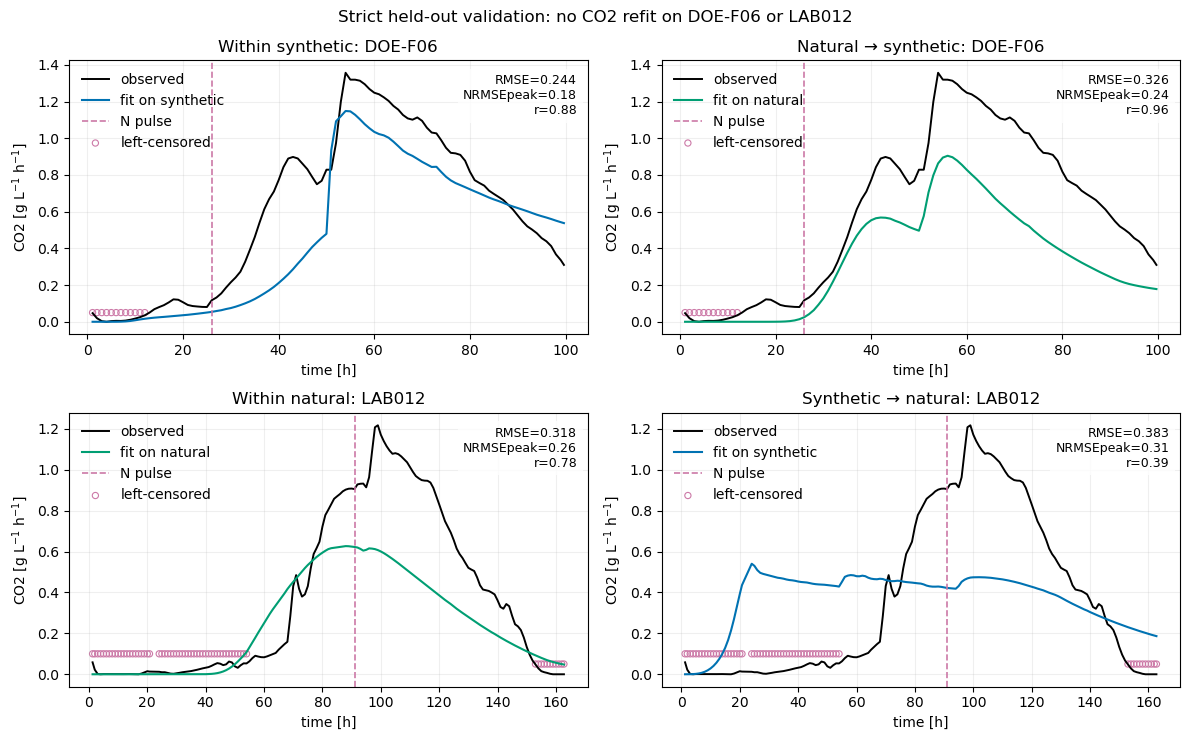

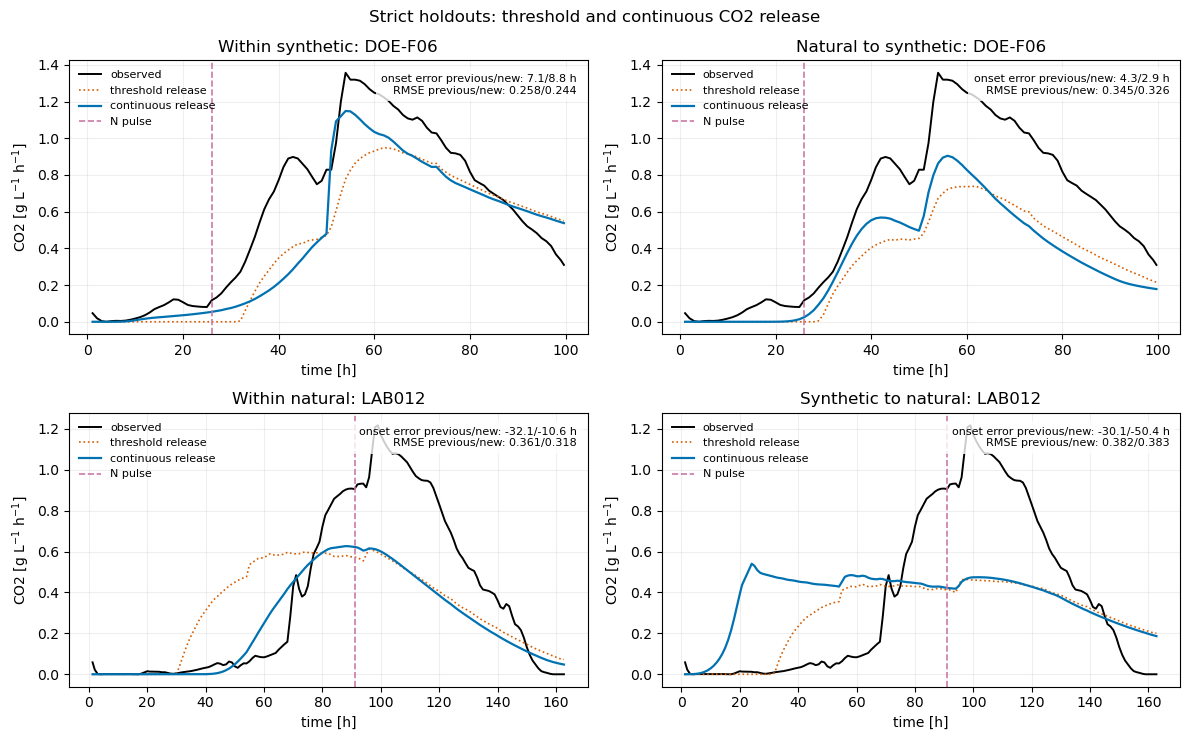

In [8]:
validation_columns = [
    "scenario", "calibration_matrix", "target_matrix", "experiment_code", "batch",
    "n", "n_total", "n_left_censored", "rmse_g_l_h", "nrmse_peak", "bias_g_l_h",
    "correlation", "r2", "integral_ratio_pred_over_observed_lower_bound",
    "observed_onset_h", "predicted_onset_h", "onset_delay_h",
    "predicted_first_emission_0p005_h", "observed_visual_rise_duration_h",
    "predicted_visual_rise_duration_h", "visual_rise_duration_error_h",
    "pulse_time_h", "observed_postpulse_peak_h", "predicted_postpulse_peak_h",
    "postpulse_peak_delay_h"
]
display(result["validation"][validation_columns])
display(result["model_comparison"])
display(result["filter_impact"])
fig = analysis.plot_validation(result["predictions"], result["validation"], save=False)
plt.show()
fig = analysis.plot_validation_model_comparison(
    result["predictions"], result["previous_predictions"],
    result["validation"], result["previous_validation"], save=False
)
plt.show()

`model_comparison` usa exactamente los mismos holdouts para la liberación por umbral anterior y la liberación continua nueva, conservando la misma respuesta finita al pulso. Valores negativos en las columnas `*_change_continuous_minus_threshold_release` significan mejora. `filter_impact` compara los ajustes crudo y filtrado sobre el mismo soporte cuantificable.

## Diagnóstico por fermentación

In [9]:
display(result["batch_metrics"][[
    "calibration_matrix", "target_matrix", "experiment_code", "batch", "role",
    "n", "n_left_censored", "rmse_g_l_h", "nrmse_peak", "bias_g_l_h",
    "correlation", "integral_ratio_pred_over_observed_lower_bound",
    "observed_onset_h", "predicted_onset_h", "onset_delay_h", "pulse_time_h",
    "predicted_first_emission_0p005_h", "observed_visual_rise_duration_h",
    "predicted_visual_rise_duration_h", "visual_rise_duration_error_h",
    "observed_postpulse_peak_h", "predicted_postpulse_peak_h",
    "postpulse_peak_delay_h"
]].sort_values(["calibration_matrix", "target_matrix", "batch"]))

,calibration_matrix,target_matrix,experiment_code,batch,role,n,n_left_censored,rmse_g_l_h,nrmse_peak,bias_g_l_h,correlation,integral_ratio_pred_over_observed_lower_bound,observed_onset_h,predicted_onset_h,onset_delay_h,pulse_time_h,predicted_first_emission_0p005_h,observed_visual_rise_duration_h,predicted_visual_rise_duration_h,visual_rise_duration_error_h,observed_postpulse_peak_h,predicted_postpulse_peak_h,postpulse_peak_delay_h
13,natural,natural,LAB004,LAB004,calibration,97,65,0.157291,0.194948,-0.052998,0.634988,0.956651,27.735273,29.163030,1.427757,56.091667,26.870355,1.308296,1.598310,0.290014,61.0,57.0,-4.0
14,natural,natural,LAB005,LAB005,calibration,119,43,0.075453,0.106871,0.019283,0.926601,1.092687,22.576040,23.020735,0.444695,55.086614,18.858831,10.599277,2.262296,-8.336980,56.0,56.0,0.0
15,natural,natural,LAB006,LAB006,calibration,139,71,0.087672,0.214141,0.057446,0.777247,1.360551,36.543760,36.181485,-0.362275,74.000000,26.456580,33.181485,6.142272,-27.039213,74.0,75.0,1.0
16,natural,natural,LAB007,LAB007,calibration,101,60,0.172832,0.209016,-0.104526,0.848006,0.902200,26.797300,23.353409,-3.443891,56.246154,18.356299,12.900109,3.206991,-9.693118,57.0,57.0,0.0
17,natural,natural,LAB008,LAB008,calibration,114,47,0.090616,0.133800,-0.000739,0.892337,1.065078,20.661926,23.810561,3.148634,56.750000,18.729115,12.036962,2.664896,-9.372066,90.0,57.0,-33.0
18,natural,natural,LAB010,LAB010,calibration,84,101,0.052161,0.139209,0.034038,0.941305,1.153160,83.423205,78.159054,-5.264151,102.494530,64.124937,68.111733,6.169714,-61.942019,106.0,113.0,7.0
19,natural,natural,LAB011,LAB011,calibration,76,85,0.443024,0.346607,-0.349040,0.826919,0.465974,68.971501,73.219398,4.247897,86.836735,62.828721,46.946272,6.243063,-40.703209,87.0,97.0,10.0
20,natural,natural,LAB012,LAB012,internal_holdout,98,63,0.318335,0.261581,-0.207234,0.776992,0.668023,65.156714,54.596645,-10.560070,91.041739,43.708807,27.311566,6.963335,-20.348230,99.0,92.0,-7.0
21,natural,synthetic,DOE-F01,lot1_F1,cross_context,178,35,0.301077,0.572809,0.279119,0.892704,2.287935,16.399541,23.153893,6.754353,NaN,19.014641,16.149541,2.244838,-13.904703,NaN,NaN,NaN
22,natural,synthetic,DOE-F03,lot1_F3,cross_context,156,57,0.220950,0.267555,-0.114169,0.452838,0.684086,20.640551,24.625903,3.985352,24.500000,19.219282,10.049108,2.733834,-7.315275,56.0,37.0,-19.0


## Experimento pendiente para distinguir sensor de biología

El umbral dependiente de temperatura sigue siendo operacional, no un LOD/LOQ certificado. Para identificarlo se requiere un ensayo a 15, 18 y 21 °C con el mismo medio y volumen, referencia independiente de CO₂ y escalones de 0.01–0.30 g CO₂ L⁻¹ h⁻¹. En cada temperatura deben estimarse LOD, LOQ, sesgo, repetibilidad y tiempo de respuesta.

La corrección por percentil inicial también es operacional. Debe reemplazarse por blancos de gas sin fermentación medidos al comienzo y al final de cada corrida en cada canal. Eso separaría offset, deriva y flujo biológico temprano sin depender de una ventana temporal elegida.

La validación biológica complementaria debe iniciar con medición química frecuente durante las primeras 48–72 h, especialmente en frío, para estrechar el intervalo de activación. Sin ese muestreo, la química sólo identifica un intervalo y no un instante exacto.

## Resumen reproducible

In [10]:
for row in result["validation"].itertuples(index=False):
    direction = f"{row.calibration_matrix} → {row.target_matrix}"
    print(
        f"{direction:22s} | {row.experiment_code:7s} | "
        f"RMSE={row.rmse_g_l_h:.3f} | r={row.correlation:.2f} | "
        f"onset error={row.onset_delay_h:.1f} h | censored={row.n_left_censored}"
    )

active = result["fit_parameters"].query("active_bound")
if not active.empty:
    print("\nAdvertencia: parámetros en límite")
    display(active)

comparison = result["model_comparison"]
print("\nDiagnóstico local de estimabilidad:")
display(result["jacobian_identifiability"])
print("\nEstabilidad leave-one-batch-out de inicio/duración:")
display(result["loo_activation_summary"])
print("\nCambio medio de |error de inicio|, nuevo - anterior [h]:",
      comparison["abs_onset_error_change_continuous_minus_threshold_release"].mean())
print("Cambio medio de RMSE, nuevo - anterior [g/L/h]:",
      comparison["rmse_change_continuous_minus_threshold_release"].mean())
print("\nCambio medio de |error de duración visual 2-10%|, nuevo - anterior [h]:",
      comparison["abs_visual_rise_duration_error_change_continuous_minus_threshold_release"].mean())
print("\nCambio medio de |error del máximo post-pulso|, nuevo - anterior [h]:",
      comparison["abs_postpulse_peak_error_change_continuous_minus_threshold_release"].mean())
print("\nArtefactos guardados en:", analysis.RESULTS_DIR.relative_to(ROOT))

synthetic → natural    | LAB012  | RMSE=0.383 | r=0.39 | onset error=-50.4 h | censored=63
natural → natural      | LAB012  | RMSE=0.318 | r=0.78 | onset error=-10.6 h | censored=63
natural → synthetic    | DOE-F06 | RMSE=0.326 | r=0.96 | onset error=2.9 h | censored=12
synthetic → synthetic  | DOE-F06 | RMSE=0.244 | r=0.88 | onset error=8.8 h | censored=12

Advertencia: parámetros en límite


,calibration_matrix,parameter,estimate,lower_bound,upper_bound,active_bound,relative_bound_distance
2,synthetic,O2_qmax_mg_gdw_h,0.150164,0.15,6.00,True,2.956747e-04
6,synthetic,chem_activation_start_fraction,0.010004,0.01,0.95,True,8.834046e-05
7,synthetic,chem_activation_duration_fraction,0.350000,0.35,2.00,True,1.204413e-09
10,natural,CO2sat_scale,0.351390,0.35,2.50,True,2.015275e-03
11,natural,O2_qmax_mg_gdw_h,0.150000,0.15,6.00,True,6.019297e-17
14,natural,pulse_activity_gain,0.250000,0.25,4.00,True,8.008566e-17



Diagnóstico local de estimabilidad:


,matrix,n_residuals,n_shape_parameters,effective_rank,condition_number_log_parameter_jacobian,smallest_singular_value,largest_singular_value,residual_variance_scale,interpretation
0,synthetic,632,8,8,2.924468e+07,2.660833e-07,7.781521,0.031275,ill_conditioned
1,natural,1216,8,8,1.298599e+02,7.868365e-02,10.217854,0.023139,moderate_or_better



Estabilidad leave-one-batch-out de inicio/duración:


,matrix,parameter,full_fit_estimate,loo_min,loo_median,loo_max,loo_range,loo_relative_range_to_full,n_omissions,n_at_lower_bound,n_at_upper_bound
0,natural,chem_activation_start_fraction,0.735057,0.735102,0.762488,0.826589,9.148752e-02,1.244632e-01,7,0,0
1,natural,chem_activation_duration_fraction,1.063910,0.371317,0.994898,1.104831,7.335145e-01,6.894518e-01,7,0,0
2,synthetic,chem_activation_start_fraction,0.010004,0.010000,0.010001,0.010002,2.019286e-06,2.018473e-04,4,4,0
3,synthetic,chem_activation_duration_fraction,0.350000,0.350000,0.350000,0.350000,3.685359e-10,1.052960e-09,4,4,0



Cambio medio de |error de inicio|, nuevo - anterior [h]: -0.23265576060281923
Cambio medio de RMSE, nuevo - anterior [g/L/h]: -0.0188319445477707

Cambio medio de |error de duración visual 2-10%|, nuevo - anterior [h]: -5.354533827243185

Cambio medio de |error del máximo post-pulso|, nuevo - anterior [h]: -1.75

Artefactos guardados en: fermentation_model\laboratory_2026\results\co2_matrix_cross_validation_2026


## Artefactos

La ejecución guarda offsets por sensor/corrida, señal antes y después de corregir cero, observaciones filtradas, soporte químico, pulsos, temperatura, parámetros y multistart, perfiles de objetivo, Jacobiano, leave-one-batch-out, predicciones, métricas, validaciones, figuras y manifiesto JSON. El notebook ejecutado conserva todas las tablas y gráficos visibles.